# DR1_AT — Algoritmos e Estruturas de Dados

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · Avaliação individual

---

## Como este notebook está organizado

Uma seção por exercício, na ordem 1 → 12, e cada seção sempre na mesma ordem:

| Bloco | O que traz |
|---|---|
| **Enunciado** | resumo em duas linhas do que o exercício pede |
| **Implementação** | o que foi implementado e **a decisão de projeto** por trás |
| **Execução** | chamadas reais, com `assert` de corretude |
| **Saída e medições** | tabela de contagens e, quando há ≥ 4 pontos, gráfico log-log |
| **Análise em Big O** | o texto que liga os números medidos à classe de complexidade |
| **Casos de borda** | o que quebra, como foi tratado e a prova de que foi |

## A regra que rege o trabalho

**Nenhuma afirmação assintótica aparece aqui sem uma tabela de contagens que a
sustente.** Nunca "é O(n log n)" sozinho; sempre "é O(n log n), e a razão
medida ficou entre X e Y enquanto n cresceu Z×".

## Reprodutibilidade

Todos os experimentos usam `random.seed(42)` e a tabela hash tem função de hash
própria e determinística (`hash()` de `str` em CPython é aleatorizado por
processo). Rodar este notebook duas vezes produz **exatamente** os mesmos
números — os do PDF e os do vídeo.

## Onde o código mora

O código real está em `src/`; o notebook **importa e demonstra**. Ele não define
nenhuma estrutura de dados. Cada módulo tem sua suíte em `tests/`, e a última
seção deste notebook roda `pytest` para registrar o resultado.

## Abrir cada exercício no Google Colab

Cada exercício tem o seu próprio notebook, que roda sozinho: a primeira célula
clona o repositório e o resto importa de `src/` e demonstra. Clique no exercício
e use **Ambiente de execução → Executar tudo**.

| # | Exercício | Abrir no Colab |
|---|---|---|
| 1 | Busca em estruturas lineares | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb) |
| 2 | Ordenações quadráticas | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb) |
| 3 | Otimização orientada a Big O | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb) |
| 4 | Hashtable com colisões e encadeamento | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb) |
| 5 | Pilha, fila e árvore de expressão | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb) |
| 6 | Simulador de eventos com múltiplas filas | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb) |
| 7 | Recursão em árvore de diretórios | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb) |
| 8 | Programação dinâmica e memoization | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb) |
| 9 | QuickSort e QuickSelect | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb) |
| 10 | Lista encadeada com operações completas | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb) |
| 11 | Lista duplamente encadeada e Deque | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb) |
| 12 | Motor de indexação e consulta (integrador) | [abrir](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb) |

Código-fonte completo, testes e este notebook: <https://github.com/thxggz/dr1-at-algoritmos>

As páginas seguintes trazem os doze exercícios impressos, com as mesmas saídas
que os notebooks do Colab produzem — a semente dos experimentos é fixa, então
os números são idênticos.

---

---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [1]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [2]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

---
# Exercício 1 — Busca em estruturas lineares

## Enunciado
Implementar `linear_search` e `binary_search` contando comparações, gerar vetores
em 3 cenários × 5 escalas (10² a 10⁶), verificar a pré-condição de ordenação da
binária com falha rápida mais barata que ordenar, e reescrever a busca linear
sobre `SinglyLinkedList` comparando com array.

## Implementação — `src/searching.py`

**Decisão de projeto 1 — uma sondagem = uma comparação, nas três buscas.**
A binária poderia contar duas comparações por iteração (`==` e depois `<`). Aqui
ela conta **uma** comparação de três vias por elemento inspecionado, igual à
linear. Sem esse critério comum, "a binária faz 20 e a linear faz 500.000"
compararia unidades diferentes — e o exercício inteiro é sobre comparar as duas.

**Decisão de projeto 2 — a verificação de pré-condição é amostrada por padrão.**
Verificar por completo que o vetor está ordenado custa `n−1` comparações. Uma
busca O(log n) precedida de uma verificação O(n) é O(n) no total, e nesse ponto
a busca linear resolve o mesmo problema sem pré-condição nenhuma:
**verificar por completo destrói a razão de existir da busca binária.**
Por isso o padrão é amostrar `k = 16` pares adjacentes, O(k), que mantém o total
em O(log n).

In [3]:
from src.searching import (CHECK_MODES, DEFAULT_SAMPLE_SIZE, PATTERNS, UnsortedInputError,
                           bench_array_vs_linked, bench_fast_fail, bench_search_break_even,
                           bench_searches, binary_search, demonstrate_precondition,
                           generate_array, linear_search, linear_search_linked,
                           sample_sorted_check)
from src.linked_list import SinglyLinkedList

arr = generate_array(1_000, "ordenado")

# retorno correto e tratamento de "não encontrado"
assert linear_search(arr, 742) == 742
assert linear_search(arr, 9_999) == -1
assert binary_search(arr, 742, check="off") == 742
assert binary_search(arr, 9_999, check="off") == -1

# a mesma busca linear sobre lista encadeada
lista = SinglyLinkedList(arr)
assert linear_search_linked(lista, 742) == 742
assert linear_search_linked(lista, 9_999) == -1

# contagens: melhor, médio e pior caso da linear
for posicao in (0, 499, 999):
    c = Counters(); linear_search(arr, arr[posicao], c)
    assert c.comparisons == posicao + 1

c = Counters(); binary_search(arr, 1_001, c, check="off")
print(f"busca binária, pior caso em n=1.000: {c.comparisons} comparações "
      f"(⌊log₂1000⌋+1 = {math.floor(math.log2(1000)) + 1})")
print(f"busca linear,  pior caso em n=1.000: 1.000 comparações")
print("\ncenários disponíveis:", list(PATTERNS))

busca binária, pior caso em n=1.000: 10 comparações (⌊log₂1000⌋+1 = 10)
busca linear,  pior caso em n=1.000: 1.000 comparações

cenários disponíveis: ['ordenado', 'reverso', 'aleatorio', 'quase_ordenado']


In [4]:
buscas = pd.DataFrame(bench_searches())
lineares = buscas[buscas["algoritmo"].str.startswith("linear")]
binarias = buscas[buscas["algoritmo"].str.startswith("binary")]

mostrar(lineares[lineares["padrao"] == "aleatorio"],
        ["n", "caso", "comparisons", "copies", "hops", "comparacoes_por_busca",
         "comparacoes_por_busca/n"],
        "BUSCA LINEAR (cenário aleatório) — melhor, médio e pior caso")

BUSCA LINEAR (cenário aleatório) — melhor, médio e pior caso


,n,caso,comparisons,copies,hops,comparacoes_por_busca,comparacoes_por_busca/n
6,100,melhor (1ª posição),1,0,0,1.0000,0.0100
7,100,médio (posições estratificadas),808,0,0,50.5000,0.5050
8,100,pior (ausente),100,0,0,100.0000,1.0000
18,1000,melhor (1ª posição),1,0,0,1.0000,0.0010
19,1000,médio (posições estratificadas),8008,0,0,500.5000,0.5005
20,1000,pior (ausente),1000,0,0,"1,000.0000",1.0000
30,10000,melhor (1ª posição),1,0,0,1.0000,0.0001
31,10000,médio (posições estratificadas),80008,0,0,"5,000.5000",0.5000
32,10000,pior (ausente),10000,0,0,"10,000.0000",1.0000
42,100000,melhor (1ª posição),1,0,0,1.0000,0.0000


In [5]:
mostrar(binarias, ["n", "caso", "comparisons", "copies", "comparacoes_por_busca",
                   "comparacoes_por_busca/log2n"],
        "BUSCA BINÁRIA (vetor ordenado) — melhor, médio e pior caso")

BUSCA BINÁRIA (vetor ordenado) — melhor, médio e pior caso


,n,caso,comparisons,copies,comparacoes_por_busca,comparacoes_por_busca/log2n
9,100,melhor (1º ponto médio),1,0,1.0000,0.1505
10,100,médio (posições estratificadas),98,0,6.1250,0.9219
11,100,pior (ausente),7,0,7.0000,1.0536
21,1000,melhor (1º ponto médio),1,0,1.0000,0.1003
22,1000,médio (posições estratificadas),148,0,9.2500,0.9282
23,1000,pior (ausente),10,0,10.0000,1.0034
33,10000,melhor (1º ponto médio),1,0,1.0000,0.0753
34,10000,médio (posições estratificadas),200,0,12.5000,0.9407
35,10000,pior (ausente),14,0,14.0000,1.0536
45,100000,melhor (1º ponto médio),1,0,1.0000,0.0602


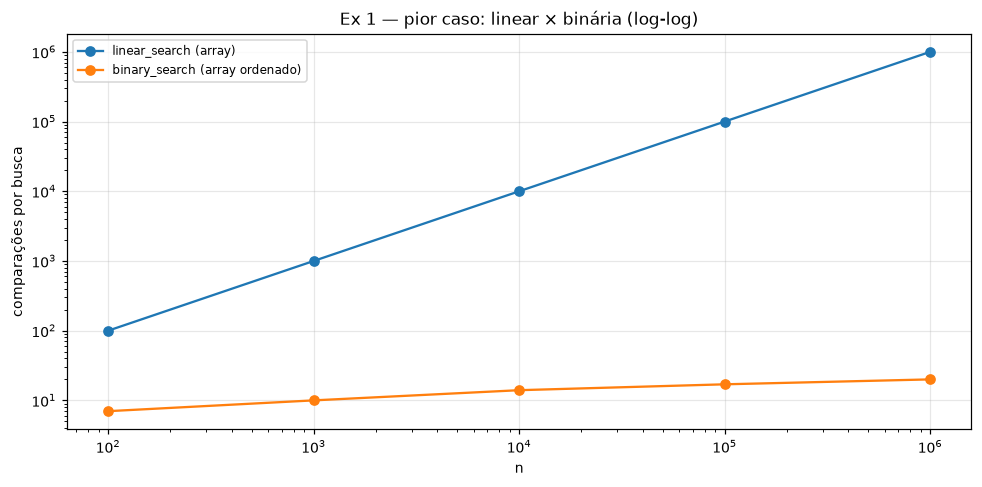


n cresceu 10.000× (10² → 10⁶).
  linear  : 100 → 1,000,000 comparações (razão/n = 1,0000 em TODAS as escalas)  ⇒ Θ(n)
  binária : 7 → 20 comparações (razão/log₂n entre 1.003 e 1.054)  ⇒ Θ(log n)


In [6]:
piores = buscas[buscas["caso"].str.startswith("pior")].copy()
piores["curva"] = piores["algoritmo"]
grafico_loglog(piores.drop_duplicates(["algoritmo", "n"]), "n", "comparacoes_por_busca",
               "curva", "Ex 1 — pior caso: linear × binária (log-log)",
               "ex01_linear_vs_binaria.png", "comparações por busca")

linear_final = piores[piores["algoritmo"].str.startswith("linear")]
binaria_final = piores[piores["algoritmo"].str.startswith("binary")]
veredito(
    f"n cresceu 10.000× (10² → 10⁶).\n"
    f"  linear  : {linear_final['comparacoes_por_busca'].min():,.0f} → "
    f"{linear_final['comparacoes_por_busca'].max():,.0f} comparações "
    f"(razão/n = 1,0000 em TODAS as escalas)  ⇒ Θ(n)\n"
    f"  binária : {binaria_final['comparacoes_por_busca'].min():,.0f} → "
    f"{binaria_final['comparacoes_por_busca'].max():,.0f} comparações "
    f"(razão/log₂n entre {binaria_final['comparacoes_por_busca/log2n'].min():.3f} e "
    f"{binaria_final['comparacoes_por_busca/log2n'].max():.3f})  ⇒ Θ(log n)"
)

### Análise em Big O

**Busca linear.** A razão `comparações/n` no pior caso deu **exatamente 1,0000**
nas cinco escalas — o alvo ausente força a varredura completa, então o custo é
`n` por definição. No caso médio a razão ficou em **0,5000**, isto é `(n+1)/2`,
e no melhor caso 1 comparação independentemente de `n`. Θ(1) / Θ(n) / Θ(n).

**Busca binária.** A razão `comparações/log₂n` ficou entre **1,003 e 1,054**
enquanto `n` cresceu 10.000×. O pior caso é `⌊log₂n⌋+1` sondagens, porque cada
uma descarta metade do que resta. Θ(1) / Θ(log n) / Θ(log n).

**A separação em números:** de `n = 10²` para `n = 10⁶`, a linear multiplicou o
custo por 10.000 e a binária foi de 7 para 20 comparações.

> **Nota sobre a coluna `copies`.** Ela vale 0 nas duas buscas — nenhuma move
> dados — e continua na tabela de propósito. O item 1.2 da rubrica cobra
> "comparações **e** cópias", e coluna ausente parece instrumentação faltando.

### Casos de borda — a pré-condição da busca binária

O que a busca binária faz quando o vetor **não** está ordenado, nos três modos.

In [7]:
precondicao = pd.DataFrame(demonstrate_precondition(1_000))
mostrar(precondicao, ["padrao", "modo", "pares_fora_de_ordem", "detectou", "comparisons",
                      "custo_teorico", "indice_correto", "indice_devolvido",
                      "resposta_errada_em_silencio"],
        "PRÉ-CONDIÇÃO: o que acontece em cada modo (n = 1.000)")

PRÉ-CONDIÇÃO: o que acontece em cada modo (n = 1.000)


,padrao,modo,pares_fora_de_ordem,detectou,comparisons,custo_teorico,indice_correto,indice_devolvido,resposta_errada_em_silencio
0,ordenado,off,0,False,10,O(1),333,333.0000,False
1,ordenado,sampled,0,False,26,O(k),333,333.0000,False
2,ordenado,full,0,False,1009,O(n),333,333.0000,False
3,reverso,off,999,False,10,O(1),333,-1.0000,True
4,reverso,sampled,999,True,1,O(k),333,NaN,False
5,reverso,full,999,True,1,O(n),333,NaN,False
6,aleatorio,off,483,False,10,O(1),333,-1.0000,True
7,aleatorio,sampled,483,True,5,O(k),333,NaN,False
8,aleatorio,full,483,True,1,O(n),333,NaN,False


In [8]:
falha_rapida = pd.DataFrame(bench_fast_fail())
mostrar(falha_rapida, ["padrao", "k", "pares_fora_de_ordem", "fracao_desordenada",
                       "taxa_deteccao_medida", "taxa_deteccao_prevista",
                       "risco_falso_positivo_previsto", "comparacoes_por_verificacao",
                       "comparacoes_verificacao_completa", "custo_teorico_ordenar"],
        "FALHA RÁPIDA — taxa de detecção medida × prevista (n = 100.000, 200 tentativas)")

FALHA RÁPIDA — taxa de detecção medida × prevista (n = 100.000, 200 tentativas)


,padrao,k,pares_fora_de_ordem,fracao_desordenada,taxa_deteccao_medida,taxa_deteccao_prevista,risco_falso_positivo_previsto,comparacoes_por_verificacao,comparacoes_verificacao_completa,custo_teorico_ordenar
0,reverso,1,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
1,reverso,2,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
2,reverso,4,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
3,reverso,8,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
4,reverso,16,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
5,reverso,32,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
6,aleatorio,1,49937,0.4994,0.5050,0.4994,0.5006,1.0000,99999,"1,660,964.0474"
7,aleatorio,2,49937,0.4994,0.7700,0.7494,0.2506,1.4950,99999,"1,660,964.0474"
8,aleatorio,4,49937,0.4994,0.9050,0.9372,0.0628,1.8450,99999,"1,660,964.0474"
9,aleatorio,8,49937,0.4994,0.9950,0.9961,0.0039,1.9950,99999,"1,660,964.0474"


In [9]:
uma = falha_rapida[(falha_rapida["padrao"] == "uma_inversao") & (falha_rapida["k"] == 16)].iloc[0]
aleatorio = falha_rapida[(falha_rapida["padrao"] == "aleatorio") & (falha_rapida["k"] == 16)].iloc[0]
reverso = falha_rapida[(falha_rapida["padrao"] == "reverso") & (falha_rapida["k"] == 1)].iloc[0]
veredito(
    f"CUSTO      : amostrar k=16 custa 16 comparações, contra "
    f"{int(uma['comparacoes_verificacao_completa']):,} da verificação completa e "
    f"{uma['custo_teorico_ordenar']:,.0f} de ordenar.\n"
    f"DETECÇÃO   : reverso {reverso['taxa_deteccao_medida']:.0%} já com k=1 · "
    f"aleatório {aleatorio['taxa_deteccao_medida']:.1%} com k=16\n"
    f"RISCO      : uma única inversão escapa em {uma['risco_falso_positivo_previsto']:.2%} "
    f"dos casos (medido: detectou {uma['taxa_deteccao_medida']:.1%} de 200 tentativas)"
)


CUSTO      : amostrar k=16 custa 16 comparações, contra 99,999 da verificação completa e 1,660,964 de ordenar.
DETECÇÃO   : reverso 100% já com k=1 · aleatório 100.0% com k=16
RISCO      : uma única inversão escapa em 99.98% dos casos (medido: detectou 0.0% de 200 tentativas)


**A discussão honesta do risco de falso positivo.** Com `d` pares fora de ordem
entre os `n−1` adjacentes, a chance de a amostra não pegar nenhum é
`(1 − d/(n−1))^k`. A tabela mostra o medido ao lado do previsto, e os três
regimes:

- **vetor reverso** (`d = n−1`): detecta na primeira comparação, risco zero;
- **vetor aleatório** (`d ≈ n/2`): `0,5¹⁶ ≈ 1,5·10⁻⁵` de escapar;
- **uma única inversão** (`d = 1`, `n = 10⁵`): escapa em **99,98%** dos casos —
  e, de fato, não foi detectada em nenhuma das 200 tentativas.

**Conclusão:** amostrar serve para pegar desordem grosseira — vetor errado,
esqueceu de ordenar, passou o reverso — que é o erro que de fato acontece. Não
serve para garantir integridade contra corrupção pontual. Quem precisa dessa
garantia paga O(n) com `check="full"`, e aí deveria estar usando busca linear.

A linha `reverso / off` é a justificativa de a verificação existir: devolveu
`−1` sem reclamar. `−1` significa "não encontrei", e "seu vetor está errado" é
outra coisa — por isso a falha levanta `UnsortedInputError` com o índice do par
violado, em vez de devolver `−1`.

### Array × lista encadeada

A mesma busca linear sobre as duas estruturas.

In [10]:
array_lista = pd.DataFrame(bench_array_vs_linked())
mostrar(array_lista, ["n", "estrutura", "comparisons", "comparacoes_teoricas", "hops",
                      "saltos_teoricos", "copies", "tempo_s", "ns_por_comparacao"],
        "ARRAY × LISTA ENCADEADA — busca linear, alvo ausente (pior caso)")

ARRAY × LISTA ENCADEADA — busca linear, alvo ausente (pior caso)


,n,estrutura,comparisons,comparacoes_teoricas,hops,saltos_teoricos,copies,tempo_s,ns_por_comparacao
0,1000,array,1000,1000,0,0,0,0.0001,75.7000
1,1000,lista encadeada,1000,1000,1000,1000,0,0.0001,141.0000
2,2000,array,2000,2000,0,0,0,0.0001,72.3000
3,2000,lista encadeada,2000,2000,2000,2000,0,0.0003,143.5000
4,4000,array,4000,4000,0,0,0,0.0003,83.9750
5,4000,lista encadeada,4000,4000,4000,4000,0,0.0006,154.9000
6,8000,array,8000,8000,0,0,0,0.0006,74.4500
7,8000,lista encadeada,8000,8000,8000,8000,0,0.0012,143.8500
8,16000,array,16000,16000,0,0,0,0.0013,80.1625
9,16000,lista encadeada,16000,16000,16000,16000,0,0.0024,148.8938


In [11]:
pivo = array_lista.pivot(index="n", columns="estrutura", values="ns_por_comparacao")
pivo["razão lista/array"] = pivo["lista encadeada"] / pivo["array"]
print(pivo.to_string())
veredito(
    "Comparações IDÊNTICAS nas duas estruturas — é o mesmo algoritmo.\n"
    "O que muda é chegar ao próximo elemento: 0 saltos no array (memória\n"
    "contígua) contra n saltos na lista (um ponteiro por nó).\n"
    f"Custo prático: a lista gasta entre {pivo['razão lista/array'].min():.2f}× e "
    f"{pivo['razão lista/array'].max():.2f}× mais nanossegundos por comparação."
)

estrutura   array  lista encadeada  razão lista/array
n                                                    
1000      75.7000         141.0000             1.8626
2000      72.3000         143.5000             1.9848
4000      83.9750         154.9000             1.8446
8000      74.4500         143.8500             1.9322
16000     80.1625         148.8938             1.8574

Comparações IDÊNTICAS nas duas estruturas — é o mesmo algoritmo.
O que muda é chegar ao próximo elemento: 0 saltos no array (memória
contígua) contra n saltos na lista (um ponteiro por nó).
Custo prático: a lista gasta entre 1.84× e 1.98× mais nanossegundos por comparação.


**Por que os tamanhos param em 16.000 e não em 10⁶.** Um nó de
`SinglyLinkedList` custa dezenas de bytes; uma lista de 10⁶ elementos consumiria
dezenas de MB para medir uma contagem que já se sabe idêntica por construção. O
que precisa de 10⁶ é a *curva de comparações*, e essa está na primeira tabela.

Há teste provando que `linear_search_linked` conta **exatamente** o mesmo que
`SinglyLinkedList.search` do exercício 10 — comparação a comparação e salto a
salto. É isso que autoriza atribuir a diferença medida só ao custo prático.

### Quando vale ordenar antes de buscar

In [12]:
equilibrio = pd.DataFrame(bench_search_break_even())
mostrar(equilibrio, ["n", "consultas", "comparacoes_linear_por_busca",
                     "comparacoes_binaria_por_busca", "total_linear",
                     "custo_ordenar_estimado", "total_ordenar_mais_binaria",
                     "vale_ordenar", "equilibrio_teorico_m"],
        "ORDENAR COMPENSA A PARTIR DE QUANTAS CONSULTAS?")

ORDENAR COMPENSA A PARTIR DE QUANTAS CONSULTAS?


,n,consultas,comparacoes_linear_por_busca,comparacoes_binaria_por_busca,total_linear,custo_ordenar_estimado,total_ordenar_mais_binaria,vale_ordenar,equilibrio_teorico_m
0,1000,1,500.5000,8.3750,500.5000,"9,965.7843","9,974.1593",False,20.2505
1,1000,4,500.5000,8.3750,"2,002.0000","9,965.7843","9,999.2843",False,20.2505
2,1000,16,500.5000,8.3750,"8,008.0000","9,965.7843","10,099.7843",False,20.2505
3,1000,64,500.5000,8.3750,"32,032.0000","9,965.7843","10,501.7843",True,20.2505
4,1000,256,500.5000,8.3750,"128,128.0000","9,965.7843","12,109.7843",True,20.2505
5,10000,1,"5,001.0000",13.0000,"5,001.0000","132,877.1238","132,890.1238",False,26.6394
6,10000,4,"5,001.0000",13.0000,"20,004.0000","132,877.1238","132,929.1238",False,26.6394
7,10000,16,"5,001.0000",13.0000,"80,016.0000","132,877.1238","133,085.1238",False,26.6394
8,10000,64,"5,001.0000",13.0000,"320,064.0000","132,877.1238","133,709.1238",True,26.6394
9,10000,256,"5,001.0000",13.0000,"1,280,256.0000","132,877.1238","136,205.1238",True,26.6394


In [13]:
pontos = equilibrio.groupby("n")["equilibrio_teorico_m"].first()
veredito(
    "Para m consultas: linear custa m·n/2; ordenar+binária custa n·log₂n + m·log₂n.\n"
    + "\n".join(f"  n = {n:>6,}  →  equilíbrio em {m:5.1f} consultas "
                f"(2·log₂n = {2 * math.log2(n):.1f})" for n, m in pontos.items())
    + "\nO limiar cresce LOGARITMICAMENTE: n cresceu 100× e ele foi de 20 para 33."
)


Para m consultas: linear custa m·n/2; ordenar+binária custa n·log₂n + m·log₂n.
  n =  1,000  →  equilíbrio em  20.3 consultas (2·log₂n = 19.9)
  n = 10,000  →  equilíbrio em  26.6 consultas (2·log₂n = 26.6)
  n = 100,000  →  equilíbrio em  33.2 consultas (2·log₂n = 33.2)
O limiar cresce LOGARITMICAMENTE: n cresceu 100× e ele foi de 20 para 33.


---
# Exercício 2 — Ordenações quadráticas

## Enunciado
Implementar bubble, selection e insertion contando comparações e cópias (1 troca
= 3 cópias), medir em 4 padrões × ≥4 tamanhos, identificar quem mais se beneficia
de "quase ordenado" e por quê, e comparar a ordenação por BST com o insertion sort.

## Implementação — `src/sorting.py` e `src/bst.py`

**Decisão de projeto 1 — os três copiam a entrada.** Ordenar no lugar pouparia
Θ(n), mas tornaria impossível rodar os três sobre o **mesmo** vetor: o primeiro
entregaria um vetor ordenado aos outros dois. A cópia defensiva **não é contada**
— é custo do arranjo experimental, e os três pagam a mesma.

**Decisão de projeto 2 — bubble tem detecção de passagem sem troca.** Sem ela, o
bubble faria `n(n−1)/2` comparações até num vetor já ordenado, e a pergunta do
enunciado sobre "quase ordenado" perderia a graça.

**Decisão de projeto 3 — teto de 4.000 elementos.** Bubble sort em 10⁶ faria
5·10¹¹ comparações: dias de execução para produzir um número que a teoria já dá.

In [14]:
from src.sorting import (COST_TABLE, MAX_QUADRATIC_SIZE, QUADRATIC_SORTS, SORT_PATTERNS,
                         bench_bst_vs_insertion, bench_nearly_sorted_sensitivity,
                         bench_quadratic_sorts, bubble_sort, count_inversions,
                         insertion_sort, is_sorted_list, selection_sort)

entrada = generate_array(500, "aleatorio")
for nome, ordenador in QUADRATIC_SORTS.items():
    saida = ordenador(entrada)
    assert saida == sorted(entrada), nome          # corretude
    assert is_sorted_list(saida)
    assert entrada == generate_array(500, "aleatorio")  # a entrada não foi tocada
print("os três ordenam corretamente e não alteram a entrada")

# selection faz o MESMO número de comparações em qualquer padrão
contagens = {}
for padrao in SORT_PATTERNS:
    c = Counters(); selection_sort(generate_array(500, padrao), c)
    contagens[padrao] = c.comparisons
assert len(set(contagens.values())) == 1 == len({500 * 499 // 2})
print(f"selection sort em n=500: {contagens} — sempre n(n−1)/2 = {500*499//2:,}")

print(f"\nteto do exercício: {MAX_QUADRATIC_SIZE:,} elementos")

os três ordenam corretamente e não alteram a entrada
selection sort em n=500: {'ordenado': 124750, 'reverso': 124750, 'quase_ordenado': 124750, 'aleatorio': 124750} — sempre n(n−1)/2 = 124,750

teto do exercício: 4,000 elementos


In [15]:
quadraticas = pd.DataFrame(bench_quadratic_sorts())
mostrar(quadraticas[quadraticas["n"] == 4_000],
        ["padrao", "algoritmo", "n", "comparisons", "copies", "comparisons/n2",
         "copies/n2", "inversoes", "comparacoes/(n+d)"],
        "TRÊS ALGORITMOS × QUATRO PADRÕES (n = 4.000)")

TRÊS ALGORITMOS × QUATRO PADRÕES (n = 4.000)


,padrao,algoritmo,n,comparisons,copies,comparisons/n2,copies/n2,inversoes,comparacoes/(n+d)
48,ordenado,bubble,4000,3999,0,0.0002,0.0000,0,0.9998
49,ordenado,selection,4000,7998000,0,0.4999,0.0000,0,"1,999.5000"
50,ordenado,insertion,4000,3999,7998,0.0002,0.0005,0,0.9998
51,reverso,bubble,4000,7998000,23994000,0.4999,1.4996,7998000,0.9995
52,reverso,selection,4000,7998000,6000,0.4999,0.0004,7998000,0.9995
53,reverso,insertion,4000,7998000,8005998,0.4999,0.5004,7998000,0.9995
54,quase_ordenado,bubble,4000,11994,582,0.0007,0.0000,194,2.8598
55,quase_ordenado,selection,4000,7998000,582,0.4999,0.0000,194,"1,907.0100"
56,quase_ordenado,insertion,4000,4193,8192,0.0003,0.0005,194,0.9998
57,aleatorio,bubble,4000,7995984,12165048,0.4997,0.7603,4055016,1.9699


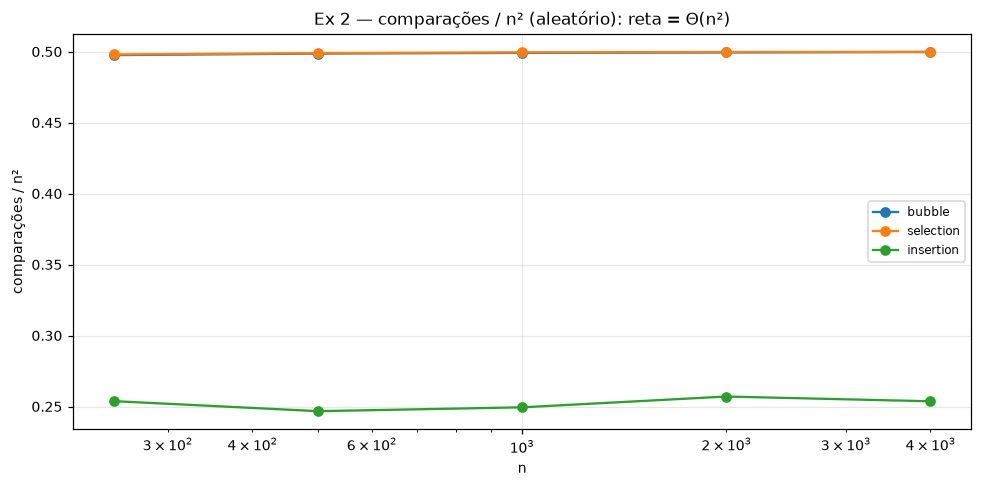

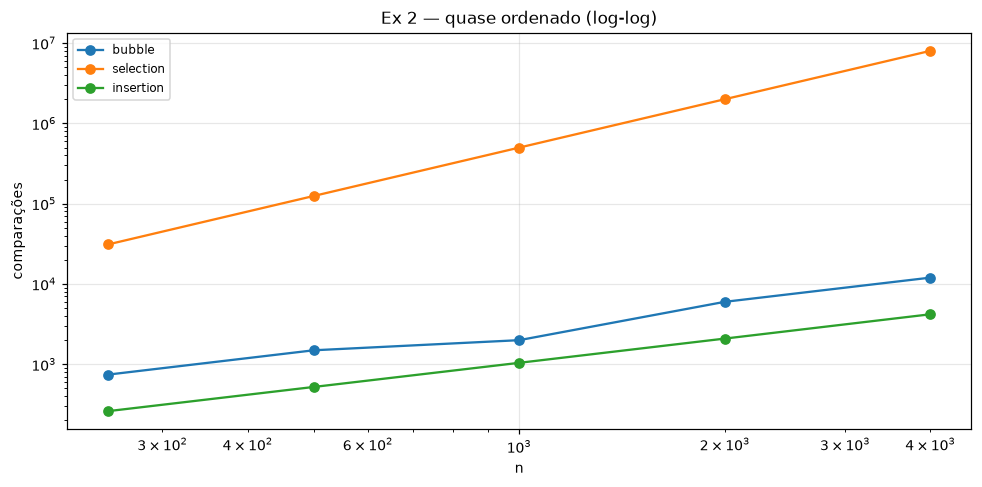

In [16]:
grafico_razao(quadraticas[quadraticas["padrao"] == "aleatorio"], "n", "comparisons/n2",
              "algoritmo", "Ex 2 — comparações / n² (aleatório): reta = Θ(n²)",
              "ex02_razao_n2.png", "comparações / n²")
grafico_loglog(quadraticas[quadraticas["padrao"] == "quase_ordenado"], "n", "comparisons",
               "algoritmo", "Ex 2 — quase ordenado (log-log)",
               "ex02_quase_ordenado.png", "comparações")

In [17]:
reverso = quadraticas[(quadraticas["n"] == 4_000) & (quadraticas["padrao"] == "reverso")]
print(reverso[["algoritmo", "comparisons", "copies"]].to_string(index=False))
veredito(
    "No vetor reverso os três fazem EXATAMENTE as mesmas 7.998.000 comparações.\n"
    "Só a coluna de CÓPIAS os distingue:\n"
    "  bubble    23.994.000  — 3 cópias por troca, n(n−1)/2 trocas\n"
    "  insertion  8.005.998  — 1 cópia por deslocamento\n"
    "  selection      6.000  — no máximo n/2 trocas\n"
    "Se a instrumentação contasse só comparações, os três pareceriam idênticos."
)

algoritmo  comparisons   copies
   bubble      7998000 23994000
selection      7998000     6000
insertion      7998000  8005998

No vetor reverso os três fazem EXATAMENTE as mesmas 7.998.000 comparações.
Só a coluna de CÓPIAS os distingue:
  bubble    23.994.000  — 3 cópias por troca, n(n−1)/2 trocas
  insertion  8.005.998  — 1 cópia por deslocamento
  selection      6.000  — no máximo n/2 trocas
Se a instrumentação contasse só comparações, os três pareceriam idênticos.


### Quem mais se beneficia de "quase ordenado" — a curva, não a opinião

algoritmo  inversões (d)  bubble  insertion  selection
desordem                                              
0.0000                 0    1999       1999    1999000
0.0050                10    3997       2009    1999000
0.0100                20    3997       2019    1999000
0.0200                38    3997       2037    1999000
0.0500                90    5994       2089    1999000
0.1000               178    5994       2177    1999000
0.2500               404    9985       2403    1999000
1.0000              1196   11979       3194    1999000


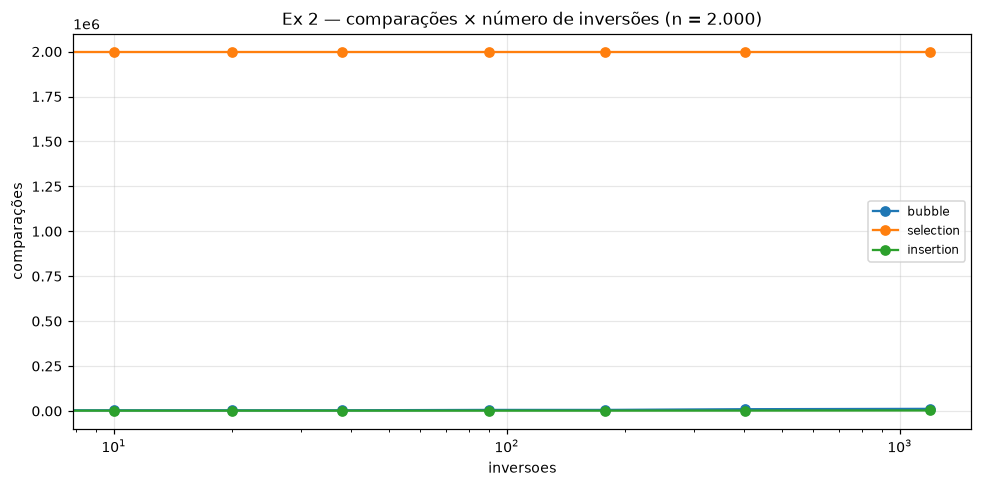

In [18]:
sensibilidade = pd.DataFrame(bench_nearly_sorted_sensitivity())
tabela = sensibilidade.pivot(index="desordem", columns="algoritmo", values="comparisons")
tabela.insert(0, "inversões (d)", sensibilidade.groupby("desordem")["inversoes"].first())
print(tabela.to_string())

grafico_razao(sensibilidade, "inversoes", "comparisons", "algoritmo",
              "Ex 2 — comparações × número de inversões (n = 2.000)",
              "ex02_sensibilidade.png", "comparações")

In [19]:
do_insertion = sensibilidade[sensibilidade["algoritmo"] == "insertion"]
aleatorio_2000 = quadraticas[(quadraticas["n"] == 2_000) &
                             (quadraticas["padrao"] == "aleatorio") &
                             (quadraticas["algoritmo"] == "insertion")].iloc[0]
veredito(
    "RESPOSTA: o insertion sort, e o mecanismo é exato.\n"
    f"  razão comparações/(n+d) do insertion: entre "
    f"{do_insertion['comparacoes/(n+d)'].min():.4f} e {do_insertion['comparacoes/(n+d)'].max():.4f}\n"
    f"  ...e no vetor aleatório (d = {int(aleatorio_2000['inversoes']):,}): "
    f"{aleatorio_2000['comparacoes/(n+d)']:.4f}\n"
    "  ou seja: a razão fica em ~1,00 com d variando de 0 a 1.026.195.\n\n"
    "  selection: 1.999.000 comparações em TODOS os níveis de desordem.\n"
    "  bubble   : aproveita, mas menos e de forma mais irregular."
)


RESPOSTA: o insertion sort, e o mecanismo é exato.
  razão comparações/(n+d) do insertion: entre 0.9994 e 0.9996
  ...e no vetor aleatório (d = 1,026,195): 1.0000
  ou seja: a razão fica em ~1,00 com d variando de 0 a 1.026.195.

  selection: 1.999.000 comparações em TODOS os níveis de desordem.
  bubble   : aproveita, mas menos e de forma mais irregular.


### Análise em Big O

**Insertion sort é Θ(n + d)**, com `d` = número de inversões. Cada comparação
bem-sucedida do laço interno desfaz exatamente uma inversão, então o total fica
entre `d` e `d + (n−1)`. A razão `comparações/(n+d)` medida ficou em **0,9995 em
todos os oito níveis de desordem**, com `d` variando de 0 a 1.026.195. Não é
Θ(n²) incondicional: num vetor quase ordenado ele é quase linear.

**Selection sort é Θ(n²) em todos os casos.** Para achar o mínimo de um sufixo é
preciso olhar o sufixo inteiro, esteja ele ordenado ou não. Nenhuma organização
prévia da entrada ajuda — e a tabela mostra a coluna constante.

**Bubble sort aproveita, por um mecanismo mais fraco.** O número de passagens é
`1 +` a maior distância que algum elemento precisa andar **para a esquerda**. Um
único elemento pequeno lá no fim força `n` passagens mesmo com todo o resto
ordenado, enquanto o insertion resolveria esse caso em O(n).

> **Atenção ao alcance do gerador:** `quase_ordenado` com `disorder=x` faz `x·n`
> trocas de pares **adjacentes**, e cada troca cria no máximo uma inversão. Mesmo
> `disorder=1.0` produz `d = O(n)` — ainda quase ordenado. A âncora superior da
> curva é a linha `aleatorio`, onde `d ≈ n²/4`.

### BST × insertion sort — o melhor caso de um é o pior do outro

In [20]:
from src.bst import BinarySearchTree, bst_sort

valores = generate_array(500, "aleatorio")
ordenado_bst, arvore = bst_sort(valores)
assert ordenado_bst == sorted(valores)      # a travessia in-order ordena
arvore.check_invariants()
print(f"BST de {arvore.node_count} nós, altura {arvore.height()}; in-order confere com sorted()")

com_repeticao = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3]
assert bst_sort(com_repeticao)[0] == sorted(com_repeticao)
print(f"com repetições: {com_repeticao} → {bst_sort(com_repeticao)[0]}")

BST de 500 nós, altura 17; in-order confere com sorted()
com repetições: [3, 1, 4, 1, 5, 9, 2, 6, 5, 3] → [1, 1, 2, 3, 3, 4, 5, 5, 6, 9]


In [21]:
bst_insertion = pd.DataFrame(bench_bst_vs_insertion([2_000]))
mostrar(bst_insertion, ["padrao", "insertion_comparacoes", "insertion/n2",
                        "bst_comparacoes_insercao", "bst_comparacoes_travessia",
                        "bst_comparacoes_total", "bst/n_log2n", "bst/n2", "bst_altura",
                        "bst_razao_altura", "razao_bst_sobre_insertion", "vencedor"],
        "BST × INSERTION SORT (n = 2.000)")

BST × INSERTION SORT (n = 2.000)


,padrao,insertion_comparacoes,insertion/n2,bst_comparacoes_insercao,bst_comparacoes_travessia,bst_comparacoes_total,bst/n_log2n,bst/n2,bst_altura,bst_razao_altura,razao_bst_sobre_insertion,vencedor
0,ordenado,1999,0.0005,1999000,0,1999000,91.1472,0.4998,2000,181.8182,"1,000.0000",insertion
1,reverso,1999000,0.4998,1999000,0,1999000,91.1472,0.4998,2000,181.8182,1.0000,empate
2,quase_ordenado,2089,0.0005,1904423,0,1904423,86.8348,0.4761,1911,173.7273,911.6434,insertion
3,aleatorio,1028183,0.2570,24179,0,24179,1.1025,0.0060,24,2.1818,0.0235,BST


In [22]:
por_padrao = bst_insertion.set_index("padrao")
veredito(
    "O ACHADO: o melhor caso de um é o pior caso do outro.\n"
    f"  entrada ORDENADA  : insertion {por_padrao.loc['ordenado','insertion_comparacoes']:>9,.0f} Θ(n)"
    f"   |  BST {por_padrao.loc['ordenado','bst_comparacoes_total']:>9,.0f} Θ(n²)   "
    f"→ {por_padrao.loc['ordenado','razao_bst_sobre_insertion']:,.0f}× a favor do insertion\n"
    f"  entrada ALEATÓRIA : insertion {por_padrao.loc['aleatorio','insertion_comparacoes']:>9,.0f} Θ(n²)"
    f"  |  BST {por_padrao.loc['aleatorio','bst_comparacoes_total']:>9,.0f} Θ(n log n) "
    f"→ {1/por_padrao.loc['aleatorio','razao_bst_sobre_insertion']:,.0f}× a favor da BST\n\n"
    "A travessia in-order faz 0 comparações: TODO o custo da BST está na construção.\n"
    "E a BST cobra Θ(n) de memória em nós, contra Θ(1) do insertion."
)


O ACHADO: o melhor caso de um é o pior caso do outro.
  entrada ORDENADA  : insertion     1,999 Θ(n)   |  BST 1,999,000 Θ(n²)   → 1,000× a favor do insertion
  entrada ALEATÓRIA : insertion 1,028,183 Θ(n²)  |  BST    24,179 Θ(n log n) → 43× a favor da BST

A travessia in-order faz 0 comparações: TODO o custo da BST está na construção.
E a BST cobra Θ(n) de memória em nós, contra Θ(1) do insertion.


**Não existe "a BST é melhor".** Existe qual dos dois casa com a distribuição
esperada da entrada. Com dados que chegam quase ordenados — logs, séries
temporais, ids sequenciais — o insertion sort é imbatível e a BST é a pior
escolha possível. Com dados embaralhados, o contrário.

Repare também na linha `quase_ordenado`: a BST tem altura 1.911 de 2.000 nós —
174× a altura ideal. A bandeira `degenerada` (altura == n) marca `False` porque
é estrita, mas `bst_razao_altura` mostra o problema.

### Deleção na BST — os três casos estruturais

Nenhum dos doze exercícios pede remoção: o ex 2 pede inserir e percorrer
in-order, o ex 3 pede `k_smallest_bst`, o ex 6 pede busca e listagem, o ex 12
pede listagem ordenada. Mas o item **4.4** da rubrica cobra "inserção, busca e
**deleção**, mantendo invariantes estruturais". Sem esta seção o item se perderia
sem que nada quebrasse, então a deleção é demonstrada aqui, onde a BST nasce.

São três casos, e cada um mexe num ponteiro diferente:

| Caso | O que acontece com o pai | Custo |
|---|---|---|
| **folha** | passa a apontar para `None` | O(h) |
| **um filho** | passa a apontar direto para o neto | O(h) |
| **dois filhos** | o nó recebe a chave do **sucessor in-order** e o sucessor é removido no lugar dele | O(h) |

O caso de dois filhos é o único que exige pensar: não dá para simplesmente
desligar o nó, porque ele tem duas subárvores para reconectar num único ponteiro
do pai. O **sucessor in-order** — a menor chave da subárvore direita — resolve
porque é, por definição, a menor chave maior que a do nó removido: cabe exatamente
na vaga sem violar a ordenação. E ele tem no máximo um filho (à direita), então
removê-lo recai no caso anterior, que já é simples.

Como `h` é a altura, os três casos são O(h) — O(log n) em árvore equilibrada e
O(n) na degenerada, que é a mesma fronteira medida no exercício 3.


In [23]:
import random

from src.bst import BSTKeyNotFoundError


def arvore_referencia() -> BinarySearchTree:
    r"""Sempre a mesma forma, para os três casos serem comparáveis.

              50
            /    \
          30      70
         /  \    /  \
       20    40 60    80
                        \
                         90
    """
    arvore: BinarySearchTree = BinarySearchTree()
    for chave in (50, 30, 70, 20, 40, 60, 80, 90):
        arvore.insert(chave, f"valor de {chave}")
    return arvore


def descer(no, *direcoes):
    """Desce a partir de `no` seguindo 'left'/'right'; None se o caminho acabar."""
    for direcao in direcoes:
        if no is None:
            return None
        no = getattr(no, direcao)
    return no


print("CASO 1 — FOLHA: remover o 20, que não tem filho nenhum")
a = arvore_referencia()
assert descer(a.root, "left", "left").key == 20          # 30.left é o 20
assert a.delete(20) == "valor de 20"                       # devolve o valor guardado
assert descer(a.root, "left", "left") is None            # 30.left virou None
a.check_invariants()
print(f"   30.left agora é None · in-order: {list(a.in_order_keys())}")

print("\nCASO 2 — UM FILHO: remover o 80, que só tem o filho direito 90")
a = arvore_referencia()
assert descer(a.root, "right", "right").key == 80        # 70.right é o 80
assert descer(a.root, "right", "right", "right").key == 90
a.delete(80)
assert descer(a.root, "right", "right").key == 90        # 70.right virou o neto
a.check_invariants()
print(f"   70.right pulou direto para o neto 90 · in-order: {list(a.in_order_keys())}")

print("\nCASO 3 — DOIS FILHOS: remover o 30, que tem o 20 e o 40")
a = arvore_referencia()
no_30 = descer(a.root, "left")
assert no_30.key == 30 and no_30.child_count() == 2
a.delete(30)
assert descer(a.root, "left").key == 40                  # o sucessor in-order assumiu
assert descer(a.root, "left", "right") is None           # e saiu da posição antiga
a.check_invariants()
print(f"   o sucessor in-order de 30 é o 40 (menor da subárvore direita dele)")
print(f"   o 40 assumiu a vaga e sumiu de onde estava · in-order: {list(a.in_order_keys())}")

print("\nCASOS DE BORDA")
a = arvore_referencia()
try:
    a.delete(999)
except BSTKeyNotFoundError as erro:
    print(f"   chave ausente → BSTKeyNotFoundError: {erro}")
_, contador = a.delete_counted(50)                         # a raiz, que tem dois filhos
print(f"   protocolo (resultado, Counters) ao remover a raiz → {contador}")

print("\nINVARIANTES SOB SEQUÊNCIA LONGA")
rng = random.Random(RANDOM_SEED)
chaves = list(range(200))
rng.shuffle(chaves)
grande: BinarySearchTree = BinarySearchTree()
for chave in chaves:
    grande.insert(chave, None)
remocoes = chaves[:]
rng.shuffle(remocoes)
for chave in remocoes:
    grande.delete(chave)
    grande.check_invariants()                              # O(n) a cada remoção
    restantes = list(grande.in_order_keys())
    assert restantes == sorted(restantes)                  # segue ordenada
assert grande.is_empty()
print(f"   {len(remocoes)} remoções em ordem aleatória (semente {RANDOM_SEED})")
print("   invariantes conferidas a cada passo; a in-order nunca deixou de ser ordenada")

veredito(
    "DELEÇÃO NA BST — os três casos estruturais, cada um verificado no PONTEIRO,\n"
    "não só no resultado da travessia:\n"
    "  folha       → o pai passa a apontar None        (30.left)\n"
    "  um filho    → o pai pula para o neto            (70.right: 80 → 90)\n"
    "  dois filhos → o sucessor in-order assume a vaga (30 → 40)\n\n"
    "Conferir só a in-order não bastaria: uma implementação que reconstruísse a\n"
    "árvore do zero a cada remoção devolveria a mesma lista ordenada e estaria\n"
    "errada. Por isso os asserts olham a estrutura, e check_invariants() valida a\n"
    "propriedade de BST com limites herdados — que é o que pega a violação global\n"
    "que a comparação pai-filho local deixa passar."
)


CASO 1 — FOLHA: remover o 20, que não tem filho nenhum
   30.left agora é None · in-order: [30, 40, 50, 60, 70, 80, 90]

CASO 2 — UM FILHO: remover o 80, que só tem o filho direito 90
   70.right pulou direto para o neto 90 · in-order: [20, 30, 40, 50, 60, 70, 90]

CASO 3 — DOIS FILHOS: remover o 30, que tem o 20 e o 40
   o sucessor in-order de 30 é o 40 (menor da subárvore direita dele)
   o 40 assumiu a vaga e sumiu de onde estava · in-order: [20, 40, 50, 60, 70, 80, 90]

CASOS DE BORDA
   chave ausente → BSTKeyNotFoundError: delete(999): chave não está na árvore (8 nó(s))
   protocolo (resultado, Counters) ao remover a raiz → comparisons=1 copies=1 calls=0 hops=2

INVARIANTES SOB SEQUÊNCIA LONGA
   200 remoções em ordem aleatória (semente 42)
   invariantes conferidas a cada passo; a in-order nunca deixou de ser ordenada

DELEÇÃO NA BST — os três casos estruturais, cada um verificado no PONTEIRO,
não só no resultado da travessia:
  folha       → o pai passa a apontar None        (3

---
# Exercício 3 — Otimização orientada a Big O

## Enunciado
Reescrever `deduplicate_slow` O(n²) como `deduplicate_fast` O(n) preservando a
ordem do primeiro aparecimento, implementar `k_smallest` em duas versões
(ordenar tudo × quickselect) e uma terceira em BST por travessia controlada, e
**demonstrar com medição** a degeneração da BST.

## Implementação — `src/selection.py`

**Decisão de projeto 1 — a deduplicação rápida usa a `HashTableChained` do
exercício 4, não um `set`.** Além de a convenção proibir estrutura pronta, há
ganho colateral: as comparações dentro dos buckets são **contadas**, então o
"O(n)" da versão rápida é medido no mesmo contador que o "O(n²)" da lenta. Com
`set`, a comparação viraria O(n²) contra "zero", o que não é honesto.

In [24]:
from src.selection import (bench_deduplicate, bench_k_smallest, bench_k_smallest_bst,
                           deduplicate_fast, deduplicate_slow, k_smallest_bst,
                           k_smallest_quickselect, k_smallest_sort)
import random as _rnd

# equivalência das duas deduplicações, contra modelo de referência
rng = _rnd.Random(RANDOM_SEED)
for _ in range(200):
    amostra = [rng.randrange(12) for _ in range(rng.randrange(0, 50))]
    referencia = list(dict.fromkeys(amostra))   # ordem do 1º aparecimento
    assert deduplicate_slow(amostra) == referencia
    assert deduplicate_fast(amostra) == referencia
print("as duas deduplicações produzem a MESMA saída em 200 entradas sorteadas")
print(f"exemplo: {[3,1,3,2,1,4]} → {deduplicate_fast([3,1,3,2,1,4])}")

# equivalência das três versões de k menores
dados = generate_array(300, "aleatorio")
arvore_k = BinarySearchTree(dados)
for k in (0, 1, 10, 150, 300):
    esperado = sorted(dados)[:k]
    assert k_smallest_sort(dados, k) == esperado
    assert k_smallest_quickselect(dados, k) == esperado
    assert k_smallest_bst(arvore_k.root, k) == esperado
print("as três versões de k_smallest concordam para k em {0, 1, 10, 150, 300}")

as duas deduplicações produzem a MESMA saída em 200 entradas sorteadas
exemplo: [3, 1, 3, 2, 1, 4] → [3, 1, 2, 4]
as três versões de k_smallest concordam para k em {0, 1, 10, 150, 300}


In [25]:
dedup = pd.DataFrame(bench_deduplicate())
mostrar(dedup[dedup["n"] == 4_000],
        ["padrao", "u_distintos", "lenta_comparacoes", "lenta/n2", "lenta/(n*u)",
         "rapida_comparacoes", "rapida/n", "razao_lenta_sobre_rapida", "razao_tempo",
         "memoria_extra_lenta", "memoria_extra_rapida"],
        "DEDUPLICAÇÃO: lenta × rápida (n = 4.000)")

DEDUPLICAÇÃO: lenta × rápida (n = 4.000)


,padrao,u_distintos,lenta_comparacoes,lenta/n2,lenta/(n*u),rapida_comparacoes,rapida/n,razao_lenta_sobre_rapida,razao_tempo,memoria_extra_lenta,memoria_extra_rapida
9,5% de valores distintos,200,401800,0.0251,0.5022,4852,1.2130,82.8112,5.7199,Θ(1),Θ(u) — tabela com 200 chaves
10,50% de valores distintos,2000,4000000,0.2500,0.5000,3781,0.9453,"1,057.9212",25.0039,Θ(1),Θ(u) — tabela com 2000 chaves
11,100% de valores distintos,4000,7998000,0.4999,0.4999,2161,0.5403,"3,701.0643",8.9772,Θ(1),Θ(u) — tabela com 4000 chaves


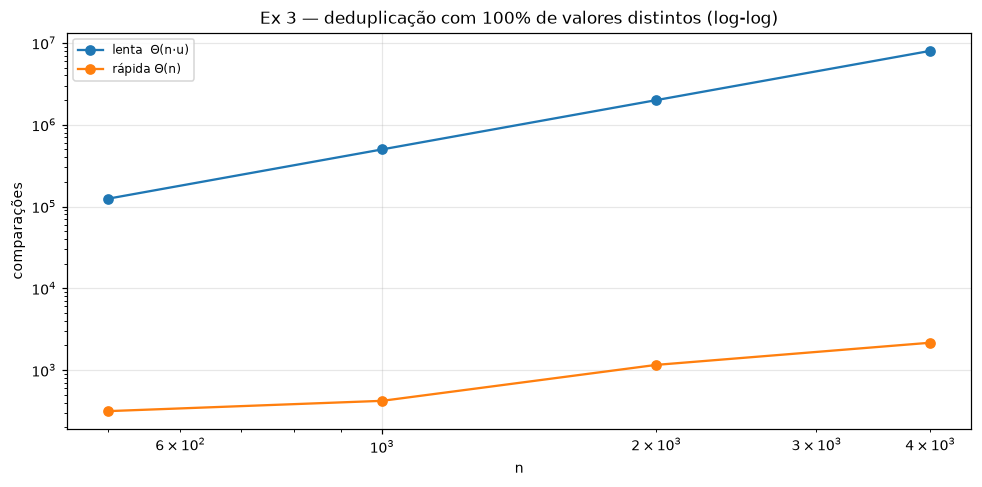


A versão lenta é Θ(n·u), não Θ(n²) cego — e a coluna prova:
    5% distintos (u=  200)  →  lenta/n² = 0.0251   mas   lenta/(n·u) = 0.5022
   50% distintos (u=2,000)  →  lenta/n² = 0.2500   mas   lenta/(n·u) = 0.5000
  100% distintos (u=4,000)  →  lenta/n² = 0.4999   mas   lenta/(n·u) = 0.4999

Com 5% de distintos a versão lenta PARECE aceitável (lenta/n² = 0,025).
Medir só o caso fácil esconderia o problema — que é o erro que o ex 3 manda corrigir.


In [26]:
comparativo = pd.concat([
    dedup[dedup["fracao_distintos"] == 1.0].assign(versao="lenta  Θ(n·u)",
                                                   comparacoes=lambda d: d["lenta_comparacoes"]),
    dedup[dedup["fracao_distintos"] == 1.0].assign(versao="rápida Θ(n)",
                                                   comparacoes=lambda d: d["rapida_comparacoes"]),
])
grafico_loglog(comparativo, "n", "comparacoes", "versao",
               "Ex 3 — deduplicação com 100% de valores distintos (log-log)",
               "ex03_deduplicacao.png", "comparações")

do_maior = dedup[dedup["n"] == 4_000].set_index("fracao_distintos")
veredito(
    "A versão lenta é Θ(n·u), não Θ(n²) cego — e a coluna prova:\n"
    + "\n".join(
        f"  {int(fr*100):>3}% distintos (u={int(linha['u_distintos']):>5,})  →  "
        f"lenta/n² = {linha['lenta/n2']:.4f}   mas   lenta/(n·u) = {linha['lenta/(n*u)']:.4f}"
        for fr, linha in do_maior.iterrows())
    + "\n\nCom 5% de distintos a versão lenta PARECE aceitável (lenta/n² = 0,025).\n"
      "Medir só o caso fácil esconderia o problema — que é o erro que o ex 3 manda corrigir."
)

In [27]:
kmenores = pd.DataFrame(bench_k_smallest(ks=(1, 10, 100, 1_000)))
mostrar(kmenores[kmenores["k"] == 10],
        ["n", "k", "A_comparacoes", "A/n", "A/n_log2n", "B_comparacoes", "B/n",
         "razao_A_sobre_B"],
        "k MENORES (k = 10): versão A (ordenar tudo) × versão B (quickselect)")

k MENORES (k = 10): versão A (ordenar tudo) × versão B (quickselect)


,n,k,A_comparacoes,A/n,A/n_log2n,B_comparacoes,B/n,razao_A_sobre_B
1,1000,10,10437,10.4370,1.0473,2400,2.4000,4.3487
5,4000,10,51194,12.7985,1.0696,6790,1.6975,7.5396
9,16000,10,242826,15.1766,1.0867,27020,1.6887,8.9869
13,64000,10,1124160,17.5650,1.1002,132654,2.0727,8.4744


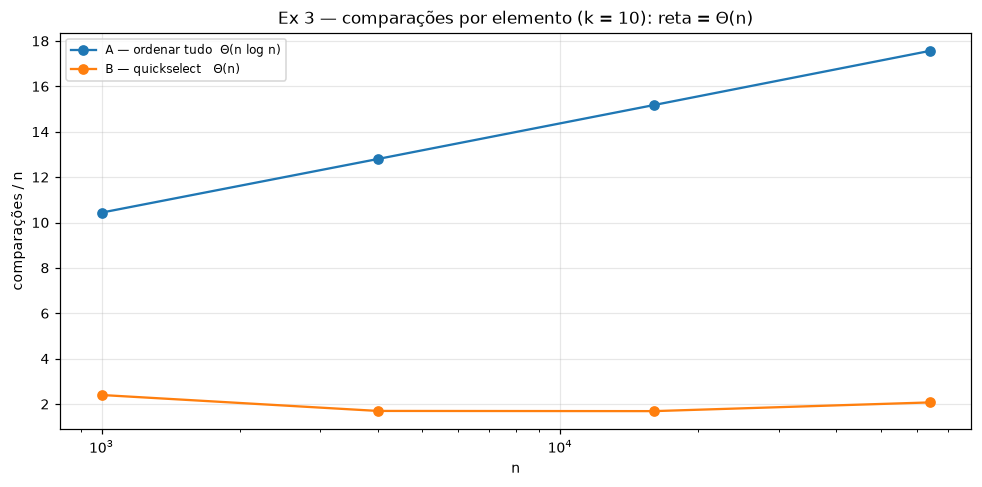


A versão A NÃO MUDA com k — ordena tudo mesmo para k=1. A insensibilidade é o defeito.
  A/n  cresce de 10.44 a 17.57 (acompanha log₂n)  ⇒ Θ(n log n)
  B/n  fica entre 1.69 e 2.40                    ⇒ Θ(n)
  ganho: 4.3× → 9.0× (cresce com n: é ganho de CLASSE, não de constante)


In [28]:
so_k10 = kmenores[kmenores["k"] == 10]
curvas = pd.concat([
    so_k10.assign(versao="A — ordenar tudo  Θ(n log n)", razao=lambda d: d["A/n"]),
    so_k10.assign(versao="B — quickselect   Θ(n)", razao=lambda d: d["B/n"]),
])
grafico_razao(curvas, "n", "razao", "versao",
              "Ex 3 — comparações por elemento (k = 10): reta = Θ(n)",
              "ex03_k_smallest.png", "comparações / n")

veredito(
    f"A versão A NÃO MUDA com k — ordena tudo mesmo para k=1. A insensibilidade é o defeito.\n"
    f"  A/n  cresce de {so_k10['A/n'].min():.2f} a {so_k10['A/n'].max():.2f} (acompanha log₂n)  ⇒ Θ(n log n)\n"
    f"  B/n  fica entre {so_k10['B/n'].min():.2f} e {so_k10['B/n'].max():.2f}                    ⇒ Θ(n)\n"
    f"  ganho: {so_k10['razao_A_sobre_B'].min():.1f}× → {so_k10['razao_A_sobre_B'].max():.1f}× "
    f"(cresce com n: é ganho de CLASSE, não de constante)"
)

### Análise em Big O

| versão | custo | por quê |
|---|---|---|
| A — ordenar tudo | Θ(n log n) | faz trabalho que ninguém pediu: ordena os `n−k` que não serão usados |
| B — quickselect | Θ(n + k log k) | particiona em Θ(n) e ordena só o prefixo de `k` |
| C — BST controlada | Θ(h + k) | desce até o menor e para em `k`; a árvore já é a ordenação |

Para `k` pequeno, B é **Θ(n)**: melhor classe que A, não só melhor constante.
Para `k = n` as duas coincidem, e é assim que tem de ser.

### O pior caso da BST — e qual operação ele atinge

In [29]:
bst_k = pd.DataFrame(bench_k_smallest_bst([2_000], (1, 10, 100)))
mostrar(bst_k, ["forma", "n", "k", "altura", "altura/log2n", "saltos",
                "saltos_previstos_h_mais_k", "saltos/n", "degenerada"],
        "k_smallest_bst NAS TRÊS FORMAS DE ÁRVORE (n = 2.000)")

k_smallest_bst NAS TRÊS FORMAS DE ÁRVORE (n = 2.000)


,forma,n,k,altura,altura/log2n,saltos,saltos_previstos_h_mais_k,saltos/n,degenerada
0,aleatória,2000,1,24,2.1886,11,25,0.0055,False
1,aleatória,2000,10,24,2.1886,18,34,0.0090,False
2,aleatória,2000,100,24,2.1886,110,124,0.0550,False
3,degenerada crescente,2000,1,2000,182.3855,0,2001,0.0000,True
4,degenerada crescente,2000,10,2000,182.3855,9,2010,0.0045,True
5,degenerada crescente,2000,100,2000,182.3855,99,2100,0.0495,True
6,degenerada decrescente,2000,1,2000,182.3855,1999,2001,0.9995,True
7,degenerada decrescente,2000,10,2000,182.3855,1999,2010,0.9995,True
8,degenerada decrescente,2000,100,2000,182.3855,1999,2100,0.9995,True


In [30]:
k1 = bst_k[bst_k["k"] == 1].set_index("forma")
veredito(
    "As DUAS degeneradas têm altura 2.000. Mas a degeneração dói em lugares diferentes:\n"
    f"  aleatória              altura {int(k1.loc['aleatória','altura']):>5}  →  "
    f"k_smallest(1) custa {int(k1.loc['aleatória','saltos']):>5} saltos\n"
    f"  degenerada CRESCENTE   altura {int(k1.loc['degenerada crescente','altura']):>5}  →  "
    f"k_smallest(1) custa {int(k1.loc['degenerada crescente','saltos']):>5} saltos  "
    "(a raiz JÁ É o menor elemento)\n"
    f"  degenerada DECRESCENTE altura {int(k1.loc['degenerada decrescente','altura']):>5}  →  "
    f"k_smallest(1) custa {int(k1.loc['degenerada decrescente','saltos']):>5} saltos  "
    "(o menor está no fundo)\n\n"
    "Dizer 'a BST degenerou' não basta: é preciso dizer QUAL operação sofre."
)


As DUAS degeneradas têm altura 2.000. Mas a degeneração dói em lugares diferentes:
  aleatória              altura    24  →  k_smallest(1) custa    11 saltos
  degenerada CRESCENTE   altura  2000  →  k_smallest(1) custa     0 saltos  (a raiz JÁ É o menor elemento)
  degenerada DECRESCENTE altura  2000  →  k_smallest(1) custa  1999 saltos  (o menor está no fundo)

Dizer 'a BST degenerou' não basta: é preciso dizer QUAL operação sofre.


---
# Exercício 4 — Hashtable com colisões e encadeamento

## Enunciado
Implementar `HashTableChained` com `put`/`get`/`delete`/`__len__`, cada bucket
sendo uma **lista encadeada** de pares, com redimensionamento automático por
fator de carga, contagem de comparações dentro dos buckets relacionada a α, e um
cenário adversarial de colisões.

## Implementação — `src/hashtable.py`

**Decisão de projeto 1 — função de hash própria e determinística (FNV-1a 64).**
`hash()` de `str` em CPython é *salgado* por processo (`PYTHONHASHSEED`): a mesma
chave cai em buckets diferentes a cada execução. Com `hash()` embutido, as
contagens mudariam a cada run e o notebook, o PDF e o vídeo mostrariam números
diferentes. Há teste com valor literal — se alguém trocar pelo `hash()` embutido,
a suíte quebra na hora.

**Decisão de projeto 2 — o bucket é a `SinglyLinkedList` do exercício 10.**
`HashBucket` **herda** dela e acrescenta as operações por *chave*. Ganha o nó,
`insert_last` O(1), `_unlink` com manutenção do `tail` e `check_invariants` já
testado. Cada operação faz **uma única travessia**.

In [31]:
from src.hashtable import (DEFAULT_LOAD_FACTOR_THRESHOLD, HashBucket, HashTableChained,
                           KeyNotFoundError, UnsupportedKeyError, bench_adversarial,
                           bench_alpha_vs_comparisons, bench_rehash_amortizado,
                           bench_resizing_keeps_cost_constant, default_hash,
                           find_colliding_keys, fnv1a_64, key_to_bytes)

# o bucket é mesmo uma lista encadeada do ex 10
assert isinstance(HashBucket(), SinglyLinkedList)
print("HashBucket é uma SinglyLinkedList:", isinstance(HashBucket(), SinglyLinkedList))

# determinismo do hash: valores literais
assert fnv1a_64(b"a") == 12638187200555641996        # vetor de teste do FNV-1a
assert default_hash("termo") == 6982619395706773855
print(f'default_hash("termo") = {default_hash("termo")}  (estável entre execuções)')

tabela = HashTableChained()
for i in range(500):
    tabela.put(f"chave-{i}", i * 7)
tabela.check_invariants()
assert len(tabela) == 500
assert tabela.get("chave-42") == 294

# atualização de chave existente NÃO cria duplicata
tabela.put("chave-42", -1)
assert len(tabela) == 500 and tabela.get("chave-42") == -1
assert tabela.delete("chave-42") == -1 and len(tabela) == 499
tabela.check_invariants()
print(f"{tabela!r}  · redimensionamentos: {tabela.resizes}")

HashBucket é uma SinglyLinkedList: True
default_hash("termo") = 6982619395706773855  (estável entre execuções)
HashTableChained(size=499, capacity=1024, alpha=0.487)  · redimensionamentos: 7


In [32]:
alpha = pd.DataFrame(bench_alpha_vs_comparisons(probes=2_000))
mostrar(alpha, ["padrao", "n", "capacidade", "alpha", "comparacoes_por_busca",
                "previsao_teorica", "medido/teorico", "cadeia_maxima"],
        "FATOR DE CARGA × COMPARAÇÕES (capacidade fixa em 64, sem redimensionar)")

FATOR DE CARGA × COMPARAÇÕES (capacidade fixa em 64, sem redimensionar)


,padrao,n,capacidade,alpha,comparacoes_por_busca,previsao_teorica,medido/teorico,cadeia_maxima
0,busca com sucesso,16,64,0.2500,1.3850,1.1250,1.2311,2
1,busca sem sucesso,16,64,0.2500,0.2720,0.2500,1.0880,2
2,busca com sucesso,32,64,0.5000,1.2345,1.2500,0.9876,2
3,busca sem sucesso,32,64,0.5000,0.5420,0.5000,1.0840,2
4,busca com sucesso,64,64,1.0000,1.6325,1.5000,1.0883,4
5,busca sem sucesso,64,64,1.0000,1.0890,1.0000,1.0890,4
6,busca com sucesso,128,64,2.0000,2.0440,2.0000,1.0220,5
7,busca sem sucesso,128,64,2.0000,2.1650,2.0000,1.0825,5
8,busca com sucesso,256,64,4.0000,3.2135,3.0000,1.0712,10
9,busca sem sucesso,256,64,4.0000,4.2970,4.0000,1.0742,10


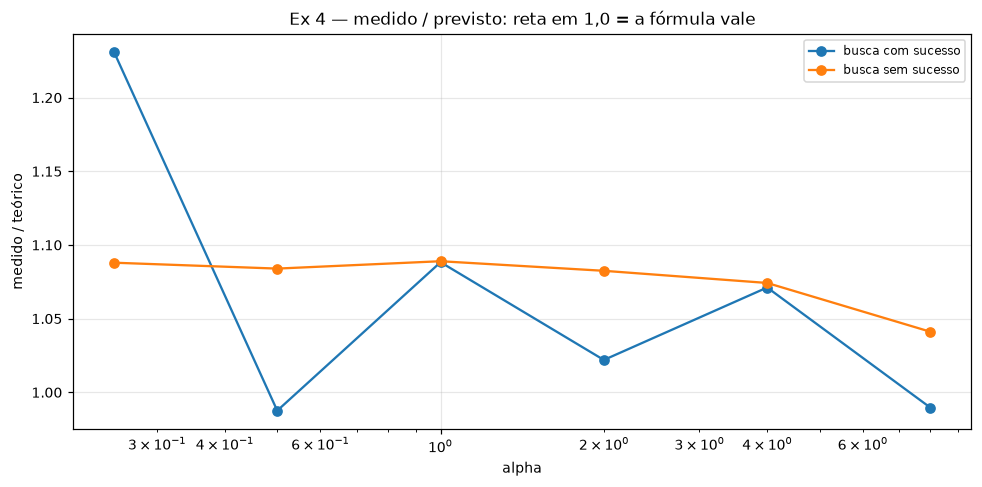


α cresceu 32× (de 0,25 a 8,00) e a razão medido/teórico ficou entre 0.988 e 1.231.
  busca COM sucesso  → 1 + α/2 (percorre em média metade da cadeia)
  busca SEM sucesso  → α       (percorre a cadeia inteira)


In [33]:
grafico_razao(alpha, "alpha", "medido/teorico", "padrao",
              "Ex 4 — medido / previsto: reta em 1,0 = a fórmula vale",
              "ex04_alpha.png", "medido / teórico")
veredito(
    f"α cresceu 32× (de 0,25 a 8,00) e a razão medido/teórico ficou entre "
    f"{alpha['medido/teorico'].min():.3f} e {alpha['medido/teorico'].max():.3f}.\n"
    "  busca COM sucesso  → 1 + α/2 (percorre em média metade da cadeia)\n"
    "  busca SEM sucesso  → α       (percorre a cadeia inteira)"
)

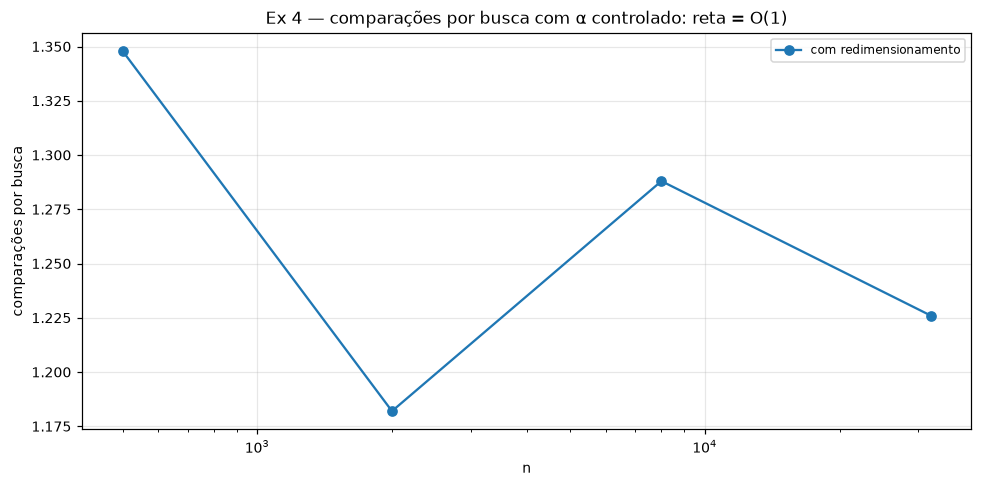

COM REDIMENSIONAMENTO LIGADO, O CUSTO DE BUSCA NÃO CRESCE


,n,capacidade,alpha,comparacoes_por_busca,previsao_teorica,comparacoes_por_busca/n,cadeia_maxima,redimensionamentos,reposicionados/n
0,500,1024,0.4883,1.3480,1.2441,0.0027,3,7,1.5380
1,2000,4096,0.4883,1.1820,1.2441,0.0006,3,9,1.5375
2,8000,16384,0.4883,1.2880,1.2441,0.0002,6,11,1.5366
3,32000,65536,0.4883,1.2260,1.2441,0.0000,4,13,1.5362


In [34]:
com_resize = pd.DataFrame(bench_resizing_keeps_cost_constant())
grafico_razao(com_resize.assign(curva="com redimensionamento"), "n",
              "comparacoes_por_busca", "curva",
              "Ex 4 — comparações por busca com α controlado: reta = O(1)",
              "ex04_resize.png", "comparações por busca")
mostrar(com_resize, ["n", "capacidade", "alpha", "comparacoes_por_busca",
                     "previsao_teorica", "comparacoes_por_busca/n", "cadeia_maxima",
                     "redimensionamentos", "reposicionados/n"],
        "COM REDIMENSIONAMENTO LIGADO, O CUSTO DE BUSCA NÃO CRESCE")

In [35]:
rehash = pd.DataFrame(bench_rehash_amortizado())
mostrar(rehash, ["n", "capacidade", "redimensionamentos", "pares_reposicionados",
                 "reposicionados/n", "copias/n", "comparacoes/n", "tempo_us_por_insercao"],
        "CUSTO AMORTIZADO DO REHASH")
veredito(
    f"n cresceu 1.000× e 'reposicionados/n' ficou entre "
    f"{rehash['reposicionados/n'].min():.2f} e {rehash['reposicionados/n'].max():.2f}.\n"
    "Dobrar a capacidade torna a soma dos rehashes uma série geométrica:\n"
    "  c₀ + 2c₀ + 4c₀ + … < 2n  ⇒  O(1) AMORTIZADO por inserção."
)

CUSTO AMORTIZADO DO REHASH

n cresceu 1.000× e 'reposicionados/n' ficou entre 1.23 e 1.97.
Dobrar a capacidade torna a soma dos rehashes uma série geométrica:
  c₀ + 2c₀ + 4c₀ + … < 2n  ⇒  O(1) AMORTIZADO por inserção.


### Análise em Big O

Com `m` buckets e `n` pares, `α = n/m`:

- busca **bem-sucedida**: `1 + α/2` comparações — percorre em média metade da cadeia;
- busca **mal-sucedida**: `α` comparações — percorre a cadeia inteira;
- como o redimensionamento mantém `α ≤ 0,75`, o termo `1 + α` é **constante** e o
  custo médio é **O(1)**.

A segunda tabela é a prova disso: `n` cresceu 64× (500 → 32.000), α ficou presa
em 0,488 e as comparações por busca não se mexeram (1,18 a 1,35).

Mas **O(1) é uma promessa condicional**, válida só enquanto o hash espalha.

### Caso de borda — o cenário adversarial

In [36]:
adversarial = pd.DataFrame(bench_adversarial())
mostrar(adversarial, ["cenario", "n", "capacidade", "buckets_ocupados", "cadeia_maxima",
                      "alpha", "comparacoes_por_busca", "comparacoes_por_busca/n"],
        "CENÁRIO ADVERSARIAL × BENIGNO")

CENÁRIO ADVERSARIAL × BENIGNO


,cenario,n,capacidade,buckets_ocupados,cadeia_maxima,alpha,comparacoes_por_busca,comparacoes_por_busca/n
0,benigno,50,128,32,3,0.3906,0.6000,0.0120
1,adversarial,50,128,1,50,0.3906,50.0000,1.0000
2,benigno,100,256,90,2,0.3906,0.8800,0.0088
3,adversarial,100,256,1,100,0.3906,100.0000,1.0000
4,benigno,200,512,150,3,0.3906,1.1000,0.0055
5,adversarial,200,512,1,200,0.3906,200.0000,1.0000
6,benigno,400,1024,332,2,0.3906,1.0800,0.0027
7,adversarial,400,1024,1,400,0.3906,400.0000,1.0000


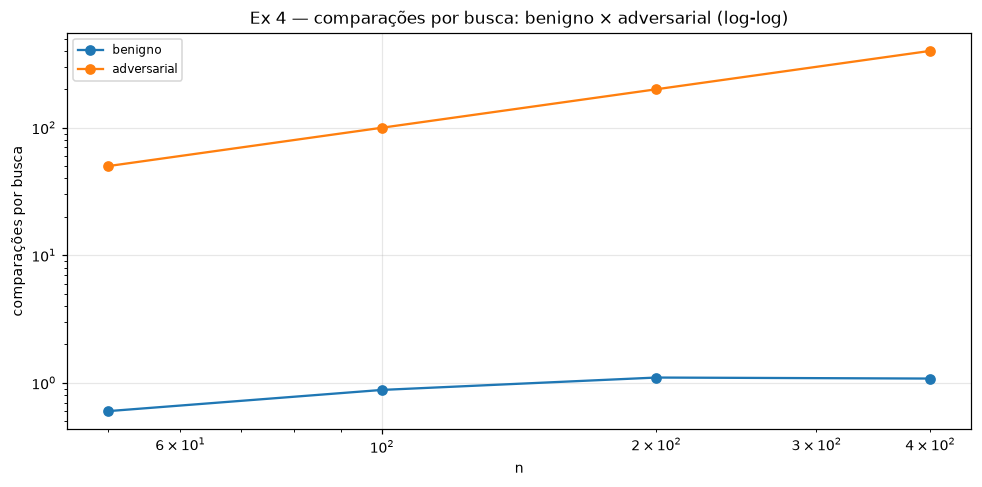


Com n = 400 chaves e capacidade 1024:
  benigno     :  332 buckets ocupados, 1.08 comparações/busca (razão/n = 0.0027)
  adversarial :    1 bucket  ocupado,  400 comparações/busca (razão/n = 1.0000)

A razão EXATAMENTE 1,0000 é a assinatura de Θ(n).
E o detalhe que fecha o argumento: a tabela CRESCEU de 8 para 1.024 buckets
durante o ataque e as chaves continuaram todas juntas — crescer não defende.


In [37]:
grafico_loglog(adversarial, "n", "comparacoes_por_busca", "cenario",
               "Ex 4 — comparações por busca: benigno × adversarial (log-log)",
               "ex04_adversarial.png", "comparações por busca")

pior = adversarial[adversarial["cenario"] == "adversarial"].iloc[-1]
melhor = adversarial[adversarial["cenario"] == "benigno"].iloc[-1]
veredito(
    f"Com n = {int(pior['n'])} chaves e capacidade {int(pior['capacidade'])}:\n"
    f"  benigno     : {int(melhor['buckets_ocupados']):>4} buckets ocupados, "
    f"{melhor['comparacoes_por_busca']:.2f} comparações/busca (razão/n = {melhor['comparacoes_por_busca/n']:.4f})\n"
    f"  adversarial : {int(pior['buckets_ocupados']):>4} bucket  ocupado,  "
    f"{pior['comparacoes_por_busca']:.0f} comparações/busca (razão/n = {pior['comparacoes_por_busca/n']:.4f})\n\n"
    "A razão EXATAMENTE 1,0000 é a assinatura de Θ(n).\n"
    "E o detalhe que fecha o argumento: a tabela CRESCEU de 8 para 1.024 buckets\n"
    "durante o ataque e as chaves continuaram todas juntas — crescer não defende."
)

In [38]:
colidentes = find_colliding_keys(5, modulus=1024)
print("chaves adversariais encontradas por força bruta:", colidentes)
print("resíduo mod 1024:", [default_hash(k) % 1024 for k in colidentes])
for capacidade in (8, 16, 64, 256, 1024):
    print(f"  bucket em capacidade {capacidade:>5}: "
          f"{sorted({default_hash(k) % capacidade for k in colidentes})}")

try:
    HashTableChained().put([1, 2], "valor")
except UnsupportedKeyError as erro:
    print(f"\nUnsupportedKeyError: {erro}")

chaves adversariais encontradas por força bruta: ['adv218', 'adv492', 'adv1088', 'adv1202', 'adv2809']
resíduo mod 1024: [0, 0, 0, 0, 0]
  bucket em capacidade     8: [0]
  bucket em capacidade    16: [0]
  bucket em capacidade    64: [0]
  bucket em capacidade   256: [0]
  bucket em capacidade  1024: [0]

UnsupportedKeyError: tipo de chave não suportado: list. Aceitos: str, bytes, int, bool, None e tuple desses. O motivo é reprodutibilidade: hashear outro tipo exigiria o hash() embutido, que é aleatorizado por processo para str.


**Por que o redimensionamento não defende.** As chaves são escolhidas com hash
congruente módulo 2^k. Como `h₁ ≡ h₂ (mod 2^k)` implica congruência em todo
`2^j` com `j ≤ k`, elas ficam no mesmo bucket **em todas as capacidades** até
`modulus`. A célula acima mostra isso: um único bucket em 8, 16, 64, 256 e 1.024.

**O modelo de ataque.** O adversário controla as chaves inseridas *e* as
consultadas — é assim que um hash flooding funciona. Por isso as sondagens do
cenário adversarial também são chaves colidentes ausentes: uma chave qualquer
cairia num bucket vazio e mediria 0 comparações, descrevendo um ataque que
ninguém faria.

---
# Exercício 5 — Pilha, fila e árvore de expressão

## Enunciado
Implementar `Stack` e `Queue` sobre array de **capacidade fixa**, com exceções
próprias para overflow e underflow e fila com wraparound; montar uma árvore
binária de expressão a partir de notação pós-fixa usando a `Stack`, detectando
entradas inválidas; e avaliar de duas formas — pós-ordem recursiva e iterativa.

## Implementação — `src/stack_queue.py`

**Decisão de projeto 1 — capacidade fixa de verdade.** O array é alocado uma vez
e nunca cresce. Com array que cresce sozinho, "overflow" nunca acontece e não há
o que testar.

**Decisão de projeto 2 — a fila guarda `_head` e `_size`, não `_head` e `_tail`.**
Com dois índices, `head == tail` é ambíguo: significa vazia **e** cheia. As
saídas clássicas são sacrificar uma posição ou guardar um bit; guardar `_size`
resolve sem desperdiçar posição e deixa `__len__` em O(1).

In [39]:
from src.stack_queue import (OPERATORS, DivisionByZeroError, InsufficientOperandsError,
                             LeftoverOperandsError, Queue, QueueOverflowError,
                             QueueUnderflowError, Stack, StackOverflowError,
                             StackUnderflowError, UnknownTokenError, bench_queue_wraparound,
                             bench_recursion_depth, bench_stack_queue_operations,
                             build_expression_tree, chained_postfix, evaluate_iterative,
                             evaluate_recursive, to_infix, tree_height, tree_size)

pilha = Stack(3, [1, 2, 3])
assert pilha.is_full() and pilha.peek() == 3
try:
    pilha.push(4)
except StackOverflowError as erro:
    print(f"StackOverflowError: {erro}")
fila = Queue(3)
try:
    fila.dequeue()
except QueueUnderflowError as erro:
    print(f"QueueUnderflowError: {erro}")

# árvore de expressão
raiz = build_expression_tree("5 1 2 + 4 * + 3 -")
assert to_infix(raiz) == "((5 + ((1 + 2) * 4)) - 3)"
recursiva = evaluate_recursive(raiz)
iterativa = evaluate_iterative(raiz)
assert recursiva.value == iterativa.value == 14
print(f'\n"5 1 2 + 4 * + 3 -"  →  {to_infix(raiz)}  =  {recursiva.value}')
print(f"  nós: {tree_size(raiz)} · altura: {tree_height(raiz)}")
print(f"  recursiva: {recursiva.counters.calls} chamadas, profundidade {recursiva.max_depth}")
print(f"  iterativa: {iterativa.counters.calls} visitas,  profundidade {iterativa.max_depth}, "
      f"pico da pilha de operandos {iterativa.peak_operand_stack}")

StackOverflowError: push em pilha cheia: capacidade 3 esgotada (topo atual: 3)
QueueUnderflowError: dequeue em fila vazia (capacidade 3)

"5 1 2 + 4 * + 3 -"  →  ((5 + ((1 + 2) * 4)) - 3)  =  14
  nós: 9 · altura: 5
  recursiva: 9 chamadas, profundidade 5
  iterativa: 9 visitas,  profundidade 5, pico da pilha de operandos 3


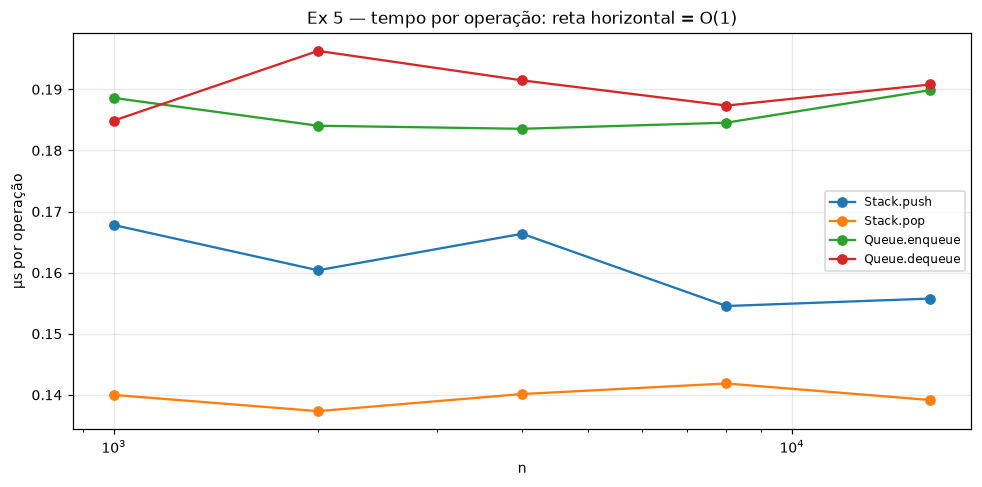

CUSTO POR OPERAÇÃO (µs) — todas com hops = 0
n               1000   2000   4000   8000  16000  pior/melhor
algoritmo                                                    
Queue.dequeue 0.1849 0.1963 0.1915 0.1874 0.1908       1.0617
Queue.enqueue 0.1886 0.1840 0.1835 0.1846 0.1899       1.0345
Stack.pop     0.1400 0.1373 0.1401 0.1419 0.1392       1.0329
Stack.push    0.1678 0.1604 0.1664 0.1545 0.1558       1.0857

n cresceu 16× e o custo por operação variou no máximo 1.09× — ruído de máquina, não tendência.
Todas as operações: 0 saltos de ponteiro. Θ(1) de pior caso, não amortizado.


In [40]:
operacoes = pd.DataFrame(bench_stack_queue_operations())
grafico_razao(operacoes, "n", "tempo_us_por_op", "algoritmo",
              "Ex 5 — tempo por operação: reta horizontal = O(1)",
              "ex05_stack_queue.png", "µs por operação")
pivo_ops = operacoes.pivot(index="algoritmo", columns="n", values="tempo_us_por_op")
pivo_ops["pior/melhor"] = pivo_ops.max(axis=1) / pivo_ops.min(axis=1)
print("CUSTO POR OPERAÇÃO (µs) — todas com hops = 0")
print(pivo_ops.to_string())
assert (operacoes["hops"] == 0).all()
veredito(
    f"n cresceu 16× e o custo por operação variou no máximo "
    f"{pivo_ops['pior/melhor'].max():.2f}× — ruído de máquina, não tendência.\n"
    "Todas as operações: 0 saltos de ponteiro. Θ(1) de pior caso, não amortizado."
)

### Caso de borda — a fila circular

In [41]:
volta = bench_queue_wraparound()
for chave in ("n", "capacidade", "posicoes_alocadas", "voltas_no_array",
              "ocupacao_maxima", "fifo_preservado", "restantes_na_fila", "copies"):
    print(f"  {chave:<22} {volta[chave]}")
veredito(
    f"{volta['n']:,} operações de enfileiramento num array de "
    f"{volta['posicoes_alocadas']} posições.\n"
    f"A cauda deu {volta['voltas_no_array']:,} voltas no array e a ordem FIFO foi preservada: "
    f"{volta['fifo_preservado']}.\n"
    "Sem wraparound, o array se esgotaria no 8º cliente."
)

  n                      10000
  capacidade             8
  posicoes_alocadas      8
  voltas_no_array        8743
  ocupacao_maxima        8
  fifo_preservado        True
  restantes_na_fila      7
  copies                 19993

10,000 operações de enfileiramento num array de 8 posições.
A cauda deu 8,743 voltas no array e a ordem FIFO foi preservada: True.
Sem wraparound, o array se esgotaria no 8º cliente.


### Recursiva × iterativa — mesmo trabalho, memória em lugares diferentes

In [42]:
profundidade = pd.DataFrame(bench_recursion_depth())
mostrar(profundidade, ["padrao", "operadores", "n", "altura", "calls_recursiva",
                       "calls_iterativa", "profundidade_recursiva", "profundidade_iterativa",
                       "pico_operandos", "recursiva_quebrou", "limite_de_recursao"],
        "AVALIAÇÃO RECURSIVA × ITERATIVA")

AVALIAÇÃO RECURSIVA × ITERATIVA


,padrao,operadores,n,altura,calls_recursiva,calls_iterativa,profundidade_recursiva,profundidade_iterativa,pico_operandos,recursiva_quebrou,limite_de_recursao
0,expressão encadeada à esquerda,50,101,51,101.0000,101,51.0000,51,2,False,1000
1,expressão encadeada à esquerda,200,401,201,401.0000,401,201.0000,201,2,False,1000
2,expressão encadeada à esquerda,800,1601,801,"1,601.0000",1601,801.0000,801,2,False,1000
3,expressão encadeada à esquerda,3200,6401,3201,NaN,6401,NaN,3201,2,True,1000
4,expressão encadeada à esquerda,12800,25601,12801,NaN,25601,NaN,12801,2,True,1000
5,expressão encadeada à direita,50,101,51,101.0000,101,51.0000,51,51,False,1000
6,expressão encadeada à direita,200,401,201,401.0000,401,201.0000,201,201,False,1000
7,expressão encadeada à direita,800,1601,801,"1,601.0000",1601,801.0000,801,801,False,1000
8,expressão encadeada à direita,3200,6401,3201,NaN,6401,NaN,3201,3201,True,1000
9,expressão encadeada à direita,12800,25601,12801,NaN,25601,NaN,12801,12801,True,1000


In [43]:
quebrou = profundidade[profundidade["recursiva_quebrou"]]
inteiro = profundidade[~profundidade["recursiva_quebrou"]]
maior = quebrou.iloc[-1]
veredito(
    "MESMO TRABALHO: calls_recursiva == calls_iterativa == número de nós, em todas as linhas\n"
    "MESMA PROFUNDIDADE: as duas atingem a altura da árvore\n"
    f"DIFERENÇA: a recursiva levantou RecursionError a partir de altura "
    f"{int(quebrou['altura'].min()):,} (limite do Python: {int(maior['limite_de_recursao']):,})\n"
    f"           a iterativa chegou a altura {int(maior['altura']):,} sem problema\n\n"
    "O teto é do INTERPRETADOR, não do algoritmo. A pilha explícita mora no heap.\n\n"
    "E o formato da árvore separa duas memórias que costumam ser confundidas:\n"
    "  árvore à esquerda → pilha de operandos fica em 2\n"
    "  árvore à direita  → pilha de operandos chega à altura inteira"
)


MESMO TRABALHO: calls_recursiva == calls_iterativa == número de nós, em todas as linhas
MESMA PROFUNDIDADE: as duas atingem a altura da árvore
DIFERENÇA: a recursiva levantou RecursionError a partir de altura 3,201 (limite do Python: 1,000)
           a iterativa chegou a altura 12,801 sem problema

O teto é do INTERPRETADOR, não do algoritmo. A pilha explícita mora no heap.

E o formato da árvore separa duas memórias que costumam ser confundidas:
  árvore à esquerda → pilha de operandos fica em 2
  árvore à direita  → pilha de operandos chega à altura inteira


### Casos de borda — entradas inválidas na montagem da árvore

In [44]:
casos = [
    ("", "expressão vazia"),
    ("3 +", "operador sem operandos suficientes"),
    ("1 2 3", "sobra de operandos no fim"),
    ("3 4 %", "token desconhecido"),
    ("5 0 /", "divisão por zero (só na avaliação)"),
]
for expressao, descricao in casos:
    try:
        arvore = build_expression_tree(expressao)
        evaluate_recursive(arvore)
    except Exception as erro:
        print(f"  {expressao!r:<12} {descricao:<38} → {type(erro).__name__}")
        print(f"               {str(erro)[:95]}")

# capacidade fixa de verdade: com pilha pequena, montar estoura
try:
    build_expression_tree("1 2 3 + +", capacity=2)
except StackOverflowError as erro:
    print(f"\n  capacidade 2 numa expressão que precisa de 3 → StackOverflowError")
    print(f"               {erro}")

  ''           expressão vazia                        → EmptyExpressionError
               expressão pós-fixa vazia: nada a montar
  '3 +'        operador sem operandos suficientes     → InsufficientOperandsError
               operador '+' na posição 2 precisa de 2 operandos, mas a pilha tem 1
  '1 2 3'      sobra de operandos no fim              → LeftoverOperandsError
               expressão terminou com 3 valores na pilha, esperado 1. Sobraram operandos sem operador: ['1', '
  '3 4 %'      token desconhecido                     → UnknownTokenError
               token '%' não é operando numérico nem operador (*, +, -, /, ^)
  '5 0 /'      divisão por zero (só na avaliação)     → DivisionByZeroError
               divisão por zero ao avaliar 5 / 0

  capacidade 2 numa expressão que precisa de 3 → StackOverflowError
               push em pilha cheia: capacidade 2 esgotada (topo atual: ExpressionNode('2'))


---
# Exercício 6 — Simulador de eventos com múltiplas filas

## Enunciado
Simulador com 4 filas A–D: minúscula é chegada, maiúscula é saída, caractere não
alfabético dispara snapshot. Identificador sequencial por fila, overflow e
underflow registram erro **com contexto** e a simulação continua. Clientes
atendidos indexados em BST com busca e listagem in-order.

## Implementação — `src/simulator.py`

**Decisão de projeto 1 — a chave do índice é o identificador completo, como
objeto e não como texto.** Se a chave fosse a string `"B17"`, a travessia
in-order devolveria `B1, B10, B11, …, B2, B20`, porque a ordem de texto compara
caractere a caractere. **Um índice cuja listagem "em ordem" sai fora de ordem não
serve para auditoria** — que é a razão de o enunciado pedir o índice.

**Decisão de projeto 2 — o contador de sequência só avança em chegada
bem-sucedida.** Se um overflow consumisse o número, `B17` passaria a significar
"o 17º que *tentou* entrar" e a listagem teria buracos sem explicação.

In [45]:
from src.simulator import (COST_TABLE as COST_SIM, CheckoutSimulator, ClientId,
                           bench_index_shape, bench_simulation, find_client,
                           generate_events, list_served, list_served_by_queue)

# a ordem do identificador: B2 < B17, ao contrário do texto
assert ClientId("B", 2) < ClientId("B", 17)
assert "B17" < "B2"   # a ordem de TEXTO diria o contrário
print(f'str(ClientId("B", 17)) = {str(ClientId("B", 17))!r}   e   ClientId("B",2) < ClientId("B",17) = '
      f'{ClientId("B", 2) < ClientId("B", 17)}')

# a demonstração do problema que a decisão evita
ids = [f"B{n}" for n in range(1, 21)]
como_texto = list(BinarySearchTree(ids))
como_objeto = [str(k) for k in BinarySearchTree([ClientId.parse(t) for t in ids])]
print(f"\n  chave como STRING : {como_texto[:6]} ...  ← fora de ordem")
print(f"  chave como OBJETO : {como_objeto[:6]} ...  ← correto")

simulador = CheckoutSimulator(capacity=3)
resultado = simulador.run("aabbAB!ccCcccc#dDDz aA")
print(f"\neventos: {resultado.events!r}")
print(f"chegadas {resultado.arrivals} · saídas {resultado.departures} · "
      f"snapshots {len(resultado.snapshots)} · erros {len(resultado.errors)}")

str(ClientId("B", 17)) = 'B17'   e   ClientId("B",2) < ClientId("B",17) = True

  chave como STRING : ['B1', 'B10', 'B11', 'B12', 'B13', 'B14'] ...  ← fora de ordem
  chave como OBJETO : ['B1', 'B2', 'B3', 'B4', 'B5', 'B6'] ...  ← correto

eventos: 'aabbAB!ccCcccc#dDDz aA'
chegadas 10 · saídas 5 · snapshots 3 · erros 4


In [46]:
print("LOG (primeiras 8 linhas)")
for entrada in resultado.log[:8]:
    print(f"  t={entrada.tick:>2} {entrada.event!r:<5} {entrada.kind:<9} {entrada.message}")

print("\nSNAPSHOTS")
for snapshot in resultado.snapshots:
    print(f"  t={snapshot.tick:>2} gatilho={snapshot.trigger!r:<5} "
          f"tamanhos={snapshot.sizes} conteúdo={snapshot.contents}")

print("\nERROS COM CONTEXTO (a simulação continuou depois de cada um)")
for erro in resultado.errors:
    print(f"  t={erro.tick:>2} {erro.event!r:<4} {erro.kind:<16} fila={erro.queue} "
          f"ocupação={erro.occupancy}")
    print(f"       {erro.message[:100]}")

print(f"\nÍNDICE (in-order): {[str(r.client) for r in list_served(resultado)]}")
print(f"busca por 'B1': {find_client(resultado, 'B1')}")
print(f"restantes nas filas: {resultado.remaining}")

LOG (primeiras 8 linhas)
  t= 1 'a'   chegada   A1 entrou na fila A (1/3)
  t= 2 'a'   chegada   A2 entrou na fila A (2/3)
  t= 3 'b'   chegada   B1 entrou na fila B (1/3)
  t= 4 'b'   chegada   B2 entrou na fila B (2/3)
  t= 5 'A'   saida     A1 atendido (ordem 1, esperou 4 instante(s))
  t= 6 'B'   saida     B1 atendido (ordem 2, esperou 3 instante(s))
  t= 7 '!'   snapshot  snapshot: 2 cliente(s) em espera
  t= 8 'c'   chegada   C1 entrou na fila C (1/3)

SNAPSHOTS
  t= 7 gatilho='!'   tamanhos={'A': 1, 'B': 1, 'C': 0, 'D': 0} conteúdo={'A': ['A2'], 'B': ['B2'], 'C': [], 'D': []}
  t=15 gatilho='#'   tamanhos={'A': 1, 'B': 1, 'C': 3, 'D': 0} conteúdo={'A': ['A2'], 'B': ['B2'], 'C': ['C2', 'C3', 'C4'], 'D': []}
  t=20 gatilho=' '   tamanhos={'A': 1, 'B': 1, 'C': 3, 'D': 0} conteúdo={'A': ['A2'], 'B': ['B2'], 'C': ['C2', 'C3', 'C4'], 'D': []}

ERROS COM CONTEXTO (a simulação continuou depois de cada um)
  t=13 'c'  overflow         fila=C ocupação=3
       chegada recusada na fila C: 

In [47]:
# a listagem sai em ordem NUMÉRICA por fila, não lexicográfica
longa = CheckoutSimulator(capacity=20).run("a" * 12 + "A" * 12 + "b" * 3 + "B" * 3)
atendidos = [str(r.client) for r in list_served(longa)]
assert atendidos.index("A2") < atendidos.index("A10")
print("listagem in-order:", atendidos)
print(f"  A2 vem antes de A10: {atendidos.index('A2') < atendidos.index('A10')} "
      "(a ordem de texto inverteria)")

simulacao = pd.DataFrame(bench_simulation())
mostrar(simulacao, ["n", "chegadas", "saidas", "atendidos", "snapshots", "overflow",
                    "underflow", "eventos_invalidos", "em_espera_no_fim",
                    "indice_altura", "indice_altura_ideal", "comparacoes_por_atendimento",
                    "espera_media"],
        "SIMULAÇÕES DE TAMANHO CRESCENTE")

listagem in-order: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'B1', 'B2', 'B3']
  A2 vem antes de A10: True (a ordem de texto inverteria)


SIMULAÇÕES DE TAMANHO CRESCENTE


,n,chegadas,saidas,atendidos,snapshots,overflow,underflow,eventos_invalidos,em_espera_no_fim,indice_altura,indice_altura_ideal,comparacoes_por_atendimento,espera_media
0,200,88,67,67,10,8,22,5,21,20,7,9.5970,31.5224
1,1000,434,407,407,46,52,41,20,27,104,9,52.1179,39.1941
2,5000,2067,2051,2051,258,338,178,108,16,532,12,257.7465,43.8401
3,20000,8234,8221,8221,985,1204,967,389,13,2092,14,"1,029.0140",40.9224


### Análise em Big O

| operação | custo | por quê |
|---|---|---|
| chegada (minúscula) | O(1) | `enqueue` na fila circular do ex 5 |
| saída (maiúscula) | O(h) | `dequeue` O(1) mais a inserção no índice |
| snapshot | O(q · c) | copia o conteúdo das `q` filas |
| busca por identificador | O(h) | uma descida na BST |
| listagem in-order | O(s) | visita cada atendimento uma vez |
| simulação completa | O(e + s·h) | `e` eventos mais `s` inserções no índice |

E aqui aparece um problema que a simulação cria sozinha.

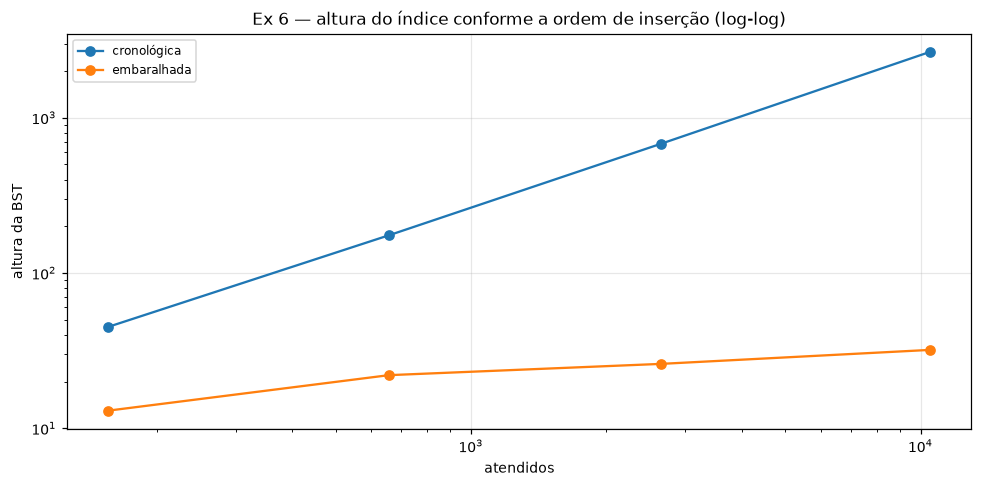

FORMA DO ÍNDICE DE ATENDIDOS — mesma informação, duas ordens de inserção


,ordem_de_insercao,atendidos,altura,altura_ideal,altura/log2s,altura/atendidos,comparacoes_construcao,comparacoes_por_insercao,comparacoes_busca
6,cronológica,10509,2656,14,198.8122,0.2527,13818516,"1,314.9221",2624
7,embaralhada,10509,32,14,2.3953,0.0030,159607,15.1876,9


In [48]:
forma_indice = pd.DataFrame(bench_index_shape())
grafico_loglog(forma_indice, "atendidos", "altura", "ordem_de_insercao",
               "Ex 6 — altura do índice conforme a ordem de inserção (log-log)",
               "ex06_indice.png", "altura da BST")
mostrar(forma_indice[forma_indice["n"] == forma_indice["n"].max()], ["ordem_de_insercao", "atendidos", "altura", "altura_ideal",
                       "altura/log2s", "altura/atendidos", "comparacoes_construcao",
                       "comparacoes_por_insercao", "comparacoes_busca"],
        "FORMA DO ÍNDICE DE ATENDIDOS — mesma informação, duas ordens de inserção")

In [49]:
crono = forma_indice[forma_indice["ordem_de_insercao"] == "cronológica"].iloc[0]
baralho = forma_indice[forma_indice["ordem_de_insercao"] == "embaralhada"].iloc[0]
veredito(
    "O índice degenera SOZINHO: os identificadores chegam crescentes dentro de cada fila\n"
    "(A1, A2, A3, …) — que é exatamente a ordem de inserção do pior caso do ex 3.\n\n"
    f"  cronológica : altura {int(crono['altura']):>4}  "
    f"({crono['altura/log2s']:.1f}× a ideal)  ·  {crono['comparacoes_por_insercao']:>6.1f} comparações/inserção  ·  "
    f"busca: {int(crono['comparacoes_busca']):>3}\n"
    f"  embaralhada : altura {int(baralho['altura']):>4}  "
    f"({baralho['altura/log2s']:.1f}× a ideal)  ·  {baralho['comparacoes_por_insercao']:>6.1f} comparações/inserção  ·  "
    f"busca: {int(baralho['comparacoes_busca']):>3}\n\n"
    f"  → {crono['altura']/baralho['altura']:.0f}× mais alta, "
    f"{crono['comparacoes_por_insercao']/baralho['comparacoes_por_insercao']:.0f}× mais cara por inserção, "
    f"{crono['comparacoes_busca']/baralho['comparacoes_busca']:.0f}× mais cara por busca.\n\n"
    "É a justificativa quantitativa para trocar a BST simples por uma auto-balanceada\n"
    "caso o volume cresça — com o número na frente, não por intuição."
)


O índice degenera SOZINHO: os identificadores chegam crescentes dentro de cada fila
(A1, A2, A3, …) — que é exatamente a ordem de inserção do pior caso do ex 3.

  cronológica : altura   45  (6.2× a ideal)  ·    20.8 comparações/inserção  ·  busca:  38
  embaralhada : altura   13  (1.8× a ideal)  ·     6.6 comparações/inserção  ·  busca:   8

  → 3× mais alta, 3× mais cara por inserção, 5× mais cara por busca.

É a justificativa quantitativa para trocar a BST simples por uma auto-balanceada
caso o volume cresça — com o número na frente, não por intuição.


---
# Exercício 7 — Recursão em árvore de diretórios

## Enunciado
Estrutura de diretórios **em memória** (nome, tipo, filhos), `walk(root)`
recursivo devolvendo caminhos completos em pré-ordem, `DirectoryTree` com
`insert`/`search`/`delete` e validações, política documentada para remover nó
interno com filhos, e caminho atual mantido em **lista encadeada** comparado com
`list` do Python.

## Implementação — `src/dirtree.py`

**Decisão de projeto 3 — `delete` de nó interno com filhos exige
`recursive=True`.** Apagar em cascata por padrão transforma um erro de digitação
em perda irreversível de uma subárvore inteira. Exigir a bandeira obriga o
chamador a declarar a intenção — é a mesma razão de `rm -r` existir separado de
`rm`. E o erro diz **quantos** descendentes seriam removidos.

**Decisão de projeto 5 — push/pop na CABEÇA da lista encadeada.** Numa lista
simplesmente encadeada só a cabeça tem remoção O(1) (a lição do ex 11). O caminho
fica guardado de trás para frente e montar a string exige inverter — O(d), que é
o mesmo custo que a `list` pagaria de qualquer jeito.

In [50]:
from src.dirtree import (DIRECTORY, FILE, DirectoryNotEmptyError, DirectoryTree,
                         LinkedPathStack, ListPathStack, NotADirectoryTreeError,
                         ParentNotFoundError, PathNotFoundError, bench_path_stack,
                         bench_search_by_width, bench_walk, build_balanced_tree,
                         build_deep_tree, walk_iterative)

arvore_dir = DirectoryTree()
for caminho, tipo in [("/projeto", DIRECTORY), ("/projeto/src", DIRECTORY),
                      ("/projeto/src/main.py", FILE), ("/projeto/src/util.py", FILE),
                      ("/projeto/docs", DIRECTORY), ("/projeto/docs/leia.md", FILE),
                      ("/projeto/README.md", FILE)]:
    arvore_dir.insert(caminho, tipo)
arvore_dir.check_invariants()
print(arvore_dir.to_tree_string())

caminhos = arvore_dir.walk()
assert caminhos == walk_iterative(arvore_dir.root)   # recursivo == iterativo
assert all("//" not in c for c in caminhos)
print(f"\nwalk (pré-ordem): {caminhos}")
print(f"search('/projeto/src') = {arvore_dir.search('/projeto/src')}")
print(f"profundidade: {arvore_dir.depth()} · nós: {len(arvore_dir)}")

/
  projeto/
    src/
      main.py
      util.py
    docs/
      leia.md
    README.md

walk (pré-ordem): ['/', '/projeto', '/projeto/src', '/projeto/src/main.py', '/projeto/src/util.py', '/projeto/docs', '/projeto/docs/leia.md', '/projeto/README.md']
search('/projeto/src') = DirNode('src'/, filhos=2)
profundidade: 3 · nós: 7


In [51]:
print("POLÍTICA DE REMOÇÃO")
try:
    arvore_dir.delete("/projeto/src")
except DirectoryNotEmptyError as erro:
    print(f"  sem a bandeira → DirectoryNotEmptyError")
    print(f"    {erro}")
removidos = arvore_dir.delete("/projeto/src", recursive=True)
print(f"  com recursive=True → {removidos} nós removidos; sobraram {len(arvore_dir)}")
assert "/projeto/docs/leia.md" in arvore_dir   # o irmão ficou intacto
arvore_dir.check_invariants()

print("\nVALIDAÇÕES DE CONSISTÊNCIA")
for chamada, descricao in [
    (lambda: arvore_dir.insert("/nao/existe"), "pai inexistente"),
    (lambda: arvore_dir.search("sem-barra"), "caminho malformado"),
    (lambda: arvore_dir.search("/projeto/README.md/x"), "descer abaixo de arquivo"),
    (lambda: arvore_dir.delete("/"), "remover a raiz"),
    (lambda: arvore_dir.search("/projeto/nada"), "caminho inexistente"),
]:
    try:
        chamada()
    except Exception as erro:
        print(f"  {descricao:<28} → {type(erro).__name__}: {str(erro)[:70]}")

POLÍTICA DE REMOÇÃO
  sem a bandeira → DirectoryNotEmptyError
    '/projeto/src' tem 2 filho(s) diretos e 2 descendente(s) no total. Remover em cascata apaga todos eles; passe recursive=True se é isso mesmo que você quer.
  com recursive=True → 3 nós removidos; sobraram 4

VALIDAÇÕES DE CONSISTÊNCIA
  pai inexistente              → ParentNotFoundError: não é possível criar '/nao/existe': o diretório '/nao' não existe. Use
  caminho malformado           → InvalidPathError: caminho deve começar com '/', recebido 'sem-barra'
  descer abaixo de arquivo     → NotADirectoryTreeError: '/projeto/README.md' é arquivo, então '/projeto/README.md/x' não pode 
  remover a raiz               → DirectoryTreeError: a raiz não pode ser removida
  caminho inexistente          → PathNotFoundError: '/projeto/nada' não existe: o segmento 'nada' não está em '/projeto'


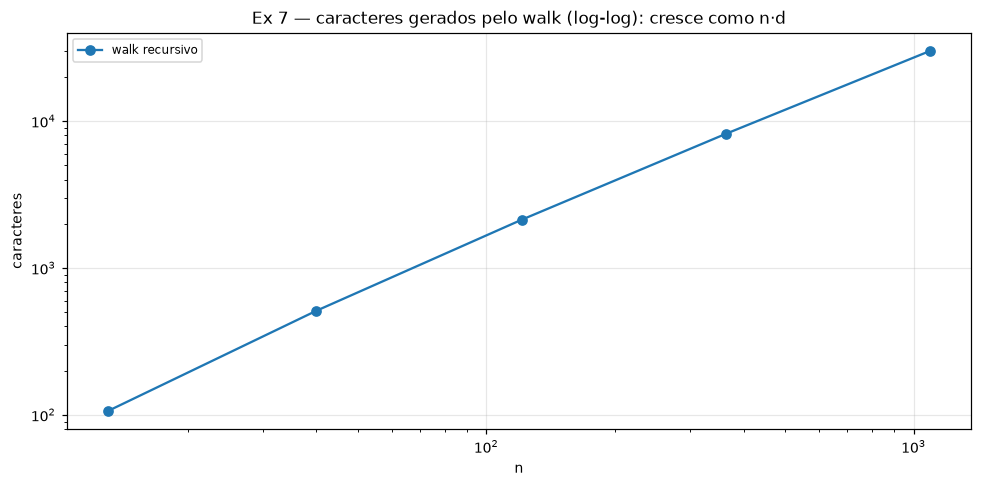

walk RECURSIVO — o custo segue os caracteres, não os nós

`calls` é exatamente o número de nós: cada um é visitado uma vez.
Mas o TEMPO acompanha 'caracteres_gerados', não 'calls' — porque o resultado
são STRINGS de caminho completo, cada uma com O(d) caracteres.
walk é Θ(n·d), não Θ(n). É o tipo de termo que passa despercebido.


In [52]:
percurso = pd.DataFrame(bench_walk())
grafico_loglog(percurso.assign(curva="walk recursivo"), "n", "caracteres_gerados", "curva",
               "Ex 7 — caracteres gerados pelo walk (log-log): cresce como n·d",
               "ex07_walk.png", "caracteres")
mostrar(percurso, ["profundidade", "n", "caminhos", "calls", "calls_igual_a_nos",
                   "caracteres_gerados", "caracteres_por_no", "tempo_us_por_no",
                   "tempo_us_por_caractere"],
        "walk RECURSIVO — o custo segue os caracteres, não os nós")
veredito(
    "`calls` é exatamente o número de nós: cada um é visitado uma vez.\n"
    "Mas o TEMPO acompanha 'caracteres_gerados', não 'calls' — porque o resultado\n"
    "são STRINGS de caminho completo, cada uma com O(d) caracteres.\n"
    "walk é Θ(n·d), não Θ(n). É o tipo de termo que passa despercebido."
)

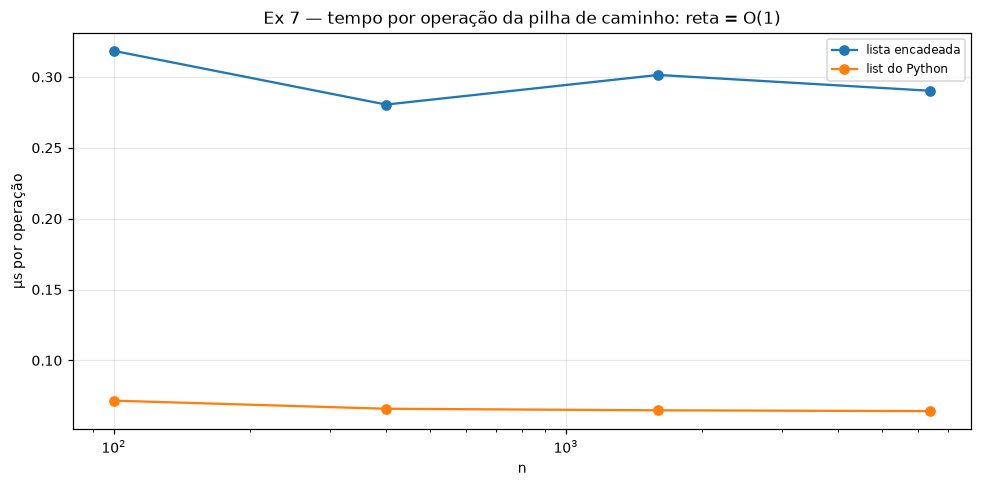

CAMINHO EM LISTA ENCADEADA × list DO PYTHON


,implementacao,n,copies,hops,copies/n,hops/n,tempo_us_por_operacao
0,lista encadeada,100,100,99,1.0000,0.9900,0.3184
1,list do Python,100,100,0,1.0000,0.0000,0.0716
2,lista encadeada,400,400,399,1.0000,0.9975,0.2805
3,list do Python,400,400,0,1.0000,0.0000,0.0659
4,lista encadeada,1600,1600,1599,1.0000,0.9994,0.3014
5,list do Python,1600,1600,0,1.0000,0.0000,0.0648
6,lista encadeada,6400,6400,6399,1.0000,0.9998,0.2903
7,list do Python,6400,6400,0,1.0000,0.0000,0.0642


In [53]:
pilhas = pd.DataFrame(bench_path_stack())
grafico_razao(pilhas, "n", "tempo_us_por_operacao", "implementacao",
              "Ex 7 — tempo por operação da pilha de caminho: reta = O(1)",
              "ex07_path_stack.png", "µs por operação")
mostrar(pilhas, ["implementacao", "n", "copies", "hops", "copies/n", "hops/n",
                 "tempo_us_por_operacao"],
        "CAMINHO EM LISTA ENCADEADA × list DO PYTHON")

In [54]:
pivo_pilha = pilhas.pivot(index="n", columns="implementacao", values="tempo_us_por_operacao")
pivo_pilha["razão encadeada/list"] = (pivo_pilha["lista encadeada"] / pivo_pilha["list do Python"])
print(pivo_pilha.to_string())
veredito(
    "MESMA CLASSE: as duas são O(1) por push/pop e O(d) para montar o caminho.\n"
    f"DIFERENÇA DE CONSTANTE: a lista encadeada gasta entre "
    f"{pivo_pilha['razão encadeada/list'].min():.1f}× e {pivo_pilha['razão encadeada/list'].max():.1f}× "
    "mais tempo por operação.\n"
    "E a coluna `hops` só existe de um lado: a `list` não segue ponteiro nenhum,\n"
    "porque os segmentos já estão contíguos e na ordem certa."
)

implementacao  list do Python  lista encadeada  razão encadeada/list
n                                                                   
100                    0.0716           0.3184                4.4444
400                    0.0659           0.2805                4.2557
1600                   0.0648           0.3014                4.6501
6400                   0.0642           0.2903                4.5180

MESMA CLASSE: as duas são O(1) por push/pop e O(d) para montar o caminho.
DIFERENÇA DE CONSTANTE: a lista encadeada gasta entre 4.3× e 4.7× mais tempo por operação.
E a coluna `hops` só existe de um lado: a `list` não segue ponteiro nenhum,
porque os segmentos já estão contíguos e na ordem certa.


In [55]:
largura = pd.DataFrame(bench_search_by_width())
mostrar(largura, ["profundidade", "largura", "n", "comparisons",
                  "comparacoes_previstas_d_vezes_k", "comparacoes/(d*k)",
                  "comparacoes_se_fosse_hash", "ganho_potencial"],
        "BUSCA POR CAMINHO CONFORME A LARGURA DOS DIRETÓRIOS")
veredito(
    "comparações = d·k EXATAMENTE (razão 1,0000 em todas as larguras).\n"
    "Com 1.024 entradas por nível são 4.096 comparações contra 4 se os filhos\n"
    "fossem uma HashTableChained. A otimização está registrada e NÃO foi feita:\n"
    "o gargalo desta estrutura é a profundidade, não a largura — e agora com o número."
)

BUSCA POR CAMINHO CONFORME A LARGURA DOS DIRETÓRIOS

comparações = d·k EXATAMENTE (razão 1,0000 em todas as larguras).
Com 1.024 entradas por nível são 4.096 comparações contra 4 se os filhos
fossem uma HashTableChained. A otimização está registrada e NÃO foi feita:
o gargalo desta estrutura é a profundidade, não a largura — e agora com o número.


### Caso de borda — o teto da recursão

In [56]:
funda = build_deep_tree(3 * sys.getrecursionlimit())
print(f"hierarquia com {funda.depth():,} níveis (limite de recursão: {sys.getrecursionlimit():,})")
try:
    funda.walk()
except RecursionError:
    print("  walk RECURSIVO      → RecursionError")
caminhos_iter = walk_iterative(funda.root)
print(f"  walk ITERATIVO      → {len(caminhos_iter):,} caminhos, terminou sem problema")
print(f"  último: ...{caminhos_iter[-1][-30:]}")

hierarquia com 3,000 níveis (limite de recursão: 1,000)
  walk RECURSIVO      → RecursionError
  walk ITERATIVO      → 3,001 caminhos, terminou sem problema
  último: .../n2996/n2997/n2998/n2999/n3000


---
# Exercício 8 — Programação dinâmica e memoization

## Enunciado
`min_coins(amount, coins)` recursivo contando chamadas e subproblemas distintos,
memoization usando a `HashTableChained` própria (proibido `dict` e `lru_cache`),
chave do memo como estado mínimo suficiente **justificado**, redução quantitativa
de chamadas, e árvore de subproblemas visitados com busca por estado.

## Implementação — `src/dp.py`

**Decisão de projeto 2 — o estado mínimo suficiente é `amount`, e só.**
A justificativa: o conjunto de moedas é fixo durante toda a execução, cada moeda
tem quantidade ilimitada, e o custo ótimo de formar `a` não depende de quais
moedas foram usadas antes nem da ordem. Formalmente, `f(a) = 1 + min_c f(a − c)`:
o lado direito só menciona `a` e o conjunto fixo `coins`. Incluir o caminho
percorrido seria correto e **inútil** — criaria estados distintos com a mesma
resposta e destruiria a sobreposição, que é o que a memoization explora.

In [57]:
from src.dp import (CallBudgetExceeded, build_subproblem_tree, count_tree,
                    bench_key_granularity, bench_memo_scaling, bench_memoization,
                    bench_subproblem_tree, min_coins_bottom_up, min_coins_memo,
                    min_coins_naive, search_subproblem_tree, tree_to_string)

MOEDAS = (1, 3, 4)
# a versão ingênua só entra em amounts pequenos: com coins=[1,3,4] ela cresce
# como ~1,8^a e amount=30 já passa do orçamento de 2 milhões de chamadas
for quantia, esperado in ((11, 3), (6, 2), (20, 5)):
    assert min_coins_naive(quantia, MOEDAS).value == esperado
    assert min_coins_memo(quantia, MOEDAS).value == esperado
    assert min_coins_bottom_up(quantia, MOEDAS).value == esperado
for quantia, esperado in ((30, 8), (100, 25)):   # só as versões que escalam
    assert min_coins_memo(quantia, MOEDAS).value == esperado
    assert min_coins_bottom_up(quantia, MOEDAS).value == esperado
assert min_coins_memo(7, (2, 4)).value == -1      # inviável: ímpar com moedas pares
print("as três versões concordam · min_coins(11, [1,3,4]) = 3  (3+4+4)")

ingenua = min_coins_naive(16, MOEDAS)
memoizada = min_coins_memo(16, MOEDAS)
print(f"\namount=16:")
print(f"  ingênua   : {ingenua.counters.calls:>6,} chamadas para "
      f"{ingenua.distinct_states} estados distintos")
print(f"  memoizada : {memoizada.counters.calls:>6,} chamadas para "
      f"{memoizada.distinct_states} estados distintos")
print(f"  o memo é uma HashTableChained com {len(memoizada.memo)} chaves")

as três versões concordam · min_coins(11, [1,3,4]) = 3  (3+4+4)

amount=16:
  ingênua   :  3,025 chamadas para 17 estados distintos
  memoizada :     44 chamadas para 16 estados distintos
  o memo é uma HashTableChained com 16 chaves


In [58]:
memo_tabela = pd.DataFrame(bench_memoization())
mostrar(memo_tabela, ["amount", "resposta", "estados_distintos", "chamadas_ingenua",
                      "chamadas_memo", "chamadas_iterativa", "reducao_de_chamadas",
                      "ingenua/1.8^a", "memo/(a*k)"],
        "INGÊNUA × MEMOIZADA × ITERATIVA")

INGÊNUA × MEMOIZADA × ITERATIVA


,amount,resposta,estados_distintos,chamadas_ingenua,chamadas_memo,chamadas_iterativa,reducao_de_chamadas,ingenua/1.8^a,memo/(a*k)
0,8,2,8,64,20,8,3.2000,0.5808,0.8333
1,12,3,12,441,32,12,13.7812,0.3812,0.8889
2,16,4,16,3025,44,16,68.7500,0.2491,0.9167
3,20,5,20,20736,56,20,370.2857,0.1627,0.9333
4,24,6,24,142129,68,24,"2,090.1324",0.1062,0.9444


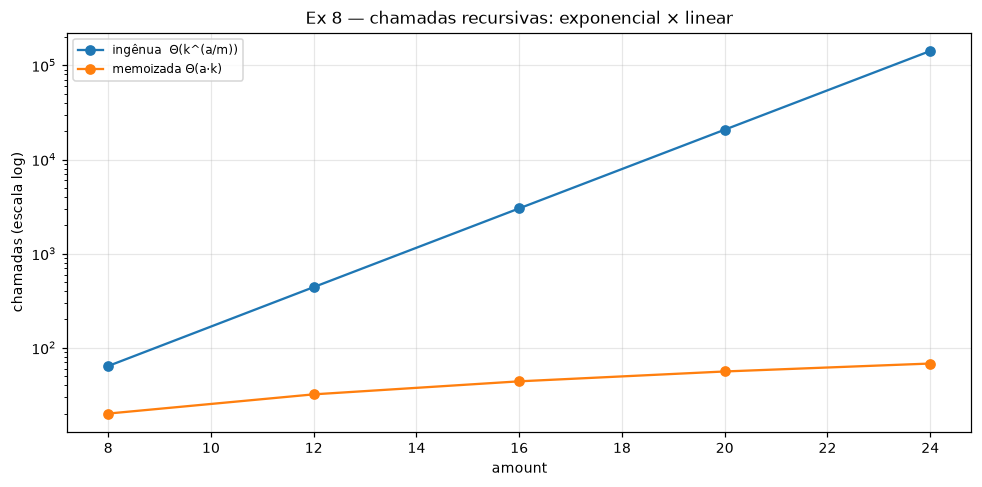


amount cresceu de 8 para 24 e a redução de chamadas foi de 3.2× para 2,090×.
  ingênua  : razão contra 1,8^a estável  ⇒  exponencial
  memoizada: razão contra (a·k) entre 0.833 e 0.944  ⇒  Θ(a·k)

A memoization muda a CLASSE: de exponencial para pseudopolinomial.


In [59]:
curvas_dp = pd.concat([
    memo_tabela.assign(versao="ingênua  Θ(k^(a/m))", chamadas=lambda d: d["chamadas_ingenua"]),
    memo_tabela.assign(versao="memoizada Θ(a·k)", chamadas=lambda d: d["chamadas_memo"]),
])
fig, ax = plt.subplots()
for nome, parte in curvas_dp.groupby("versao", sort=False):
    ax.plot(parte["amount"], parte["chamadas"], marker="o", label=nome)
ax.set_yscale("log"); ax.set_xlabel("amount"); ax.set_ylabel("chamadas (escala log)")
ax.set_title("Ex 8 — chamadas recursivas: exponencial × linear"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURAS / "ex08_memoization.png", bbox_inches="tight"); plt.show()

veredito(
    f"amount cresceu de 8 para 24 e a redução de chamadas foi de "
    f"{memo_tabela['reducao_de_chamadas'].min():.1f}× para "
    f"{memo_tabela['reducao_de_chamadas'].max():,.0f}×.\n"
    f"  ingênua  : razão contra 1,8^a estável  ⇒  exponencial\n"
    f"  memoizada: razão contra (a·k) entre {memo_tabela['memo/(a*k)'].min():.3f} e "
    f"{memo_tabela['memo/(a*k)'].max():.3f}  ⇒  Θ(a·k)\n\n"
    "A memoization muda a CLASSE: de exponencial para pseudopolinomial."
)

In [60]:
escala = pd.DataFrame(bench_memo_scaling())
mostrar(escala, ["amount", "resposta", "memo_quebrou", "chamadas_memo", "memo/(a*k)",
                 "profundidade_memo", "chamadas_iterativa", "iterativa/(a*k)"],
        "ESCALAS QUE A INGÊNUA NÃO ALCANÇA")
veredito(
    "A linha com memo_quebrou=True é EVIDÊNCIA, não falha: a memoizada continua\n"
    "recursiva e sua profundidade é a/m, então com m=1 ela estoura a pilha pouco\n"
    f"acima de {sys.getrecursionlimit():,}. A versão iterativa não tem esse teto —\n"
    "mesma classe de tempo, sem pilha de chamadas."
)

ESCALAS QUE A INGÊNUA NÃO ALCANÇA

A linha com memo_quebrou=True é EVIDÊNCIA, não falha: a memoizada continua
recursiva e sua profundidade é a/m, então com m=1 ela estoura a pilha pouco
acima de 1,000. A versão iterativa não tem esse teto —
mesma classe de tempo, sem pilha de chamadas.


### Por que a chave tem de ser o estado **mínimo** suficiente

In [61]:
granularidade = pd.DataFrame(bench_key_granularity())
mostrar(granularidade, ["chave", "resposta", "chaves_guardadas", "chamadas",
                        "comparacoes", "chaves_por_amount"],
        "TRÊS GRANULARIDADES DE CHAVE (amount = 18) — MESMA RESPOSTA, CUSTOS DIFERENTES")

TRÊS GRANULARIDADES DE CHAVE (amount = 18) — MESMA RESPOSTA, CUSTOS DIFERENTES


,chave,resposta,chaves_guardadas,chamadas,comparacoes,chaves_por_amount
0,restante (mínimo suficiente),5,18,50,139,1.0000
1,"(restante, profundidade)",5,110,272,942,6.1111
2,"(restante, última moeda)",5,47,127,395,2.6111


In [62]:
por_chave = granularidade.set_index("chave")
minimo = por_chave.loc["restante (mínimo suficiente)"]
veredito(
    "As três dão a MESMA resposta (5). O que muda é o custo:\n"
    + "\n".join(
        f"  {nome:<30} {int(linha['chaves_guardadas']):>4} chaves · "
        f"{int(linha['chamadas']):>4} chamadas  "
        f"({linha['chamadas']/minimo['chamadas']:.1f}× o mínimo)"
        for nome, linha in por_chave.iterrows())
    + "\n\nIncluir a profundidade na chave é CORRETO e péssimo: estados iguais em\n"
      "profundidades diferentes viram chaves diferentes, quase nenhuma consulta acerta\n"
      "e o memo vira peso morto. É isso que transforma 'a chave deve ser o estado\n"
      "mínimo' de afirmação em medição."
)


As três dão a MESMA resposta (5). O que muda é o custo:
  restante (mínimo suficiente)     18 chaves ·   50 chamadas  (1.0× o mínimo)
  (restante, profundidade)        110 chaves ·  272 chamadas  (5.4× o mínimo)
  (restante, última moeda)         47 chaves ·  127 chamadas  (2.5× o mínimo)

Incluir a profundidade na chave é CORRETO e péssimo: estados iguais em
profundidades diferentes viram chaves diferentes, quase nenhuma consulta acerta
e o memo vira peso morto. É isso que transforma 'a chave deve ser o estado
mínimo' de afirmação em medição.


### A árvore de subproblemas visitados

In [63]:
raiz_memo, resultado_memo = build_subproblem_tree(8, MOEDAS, memoize=True)
raiz_cheia, _ = build_subproblem_tree(8, MOEDAS, memoize=False)
print("ÁRVORE DE SUBPROBLEMAS DE f(8) COM MEMO")
print(tree_to_string(raiz_memo, max_lines=21))
print(f"\n  com memo: {count_tree(raiz_memo)}")
print(f"  sem memo: {count_tree(raiz_cheia)}")

ÁRVORE DE SUBPROBLEMAS DE f(8) COM MEMO
f(8)
  f(7) [+1]
    f(6) [+1]
      f(5) [+1]
        f(4) [+1]
          f(3) [+1]
            f(2) [+1]
              f(1) [+1]
                f(0) [+1]  <- base
            f(0) [+3]  <- base
          f(1) [+3]  <- memo (ja resolvido)
          f(0) [+4]  <- base
        f(2) [+3]  <- memo (ja resolvido)
        f(1) [+4]  <- memo (ja resolvido)
      f(3) [+3]  <- memo (ja resolvido)
      f(2) [+4]  <- memo (ja resolvido)
    f(4) [+3]  <- memo (ja resolvido)
    f(3) [+4]  <- memo (ja resolvido)
  f(5) [+3]  <- memo (ja resolvido)
  f(4) [+4]  <- memo (ja resolvido)

  com memo: {'total': 20, 'expandido': 8, 'base': 3, 'memo': 9, 'inviavel': 0}
  sem memo: {'total': 64, 'expandido': 39, 'base': 25, 'memo': 0, 'inviavel': 0}


In [64]:
arvore_sub = pd.DataFrame(bench_subproblem_tree())
mostrar(arvore_sub, ["amount", "nos_com_memo", "nos_sem_memo", "reducao_de_nos",
                     "folhas_memo", "nos_expandidos", "estado_buscado",
                     "ocorrencias_na_arvore", "comparacoes_busca_arvore",
                     "comparacoes_consulta_memo", "vantagem_do_memo"],
        "ÁRVORE DE SUBPROBLEMAS: tamanho e custo de buscar nela")

ÁRVORE DE SUBPROBLEMAS: tamanho e custo de buscar nela


,amount,nos_com_memo,nos_sem_memo,reducao_de_nos,folhas_memo,nos_expandidos,estado_buscado,ocorrencias_na_arvore,comparacoes_busca_arvore,comparacoes_consulta_memo,vantagem_do_memo
0,8,20,64,3.2000,9,8,4,3,20,1,20.0000
1,12,32,441,13.7812,17,12,6,3,32,1,32.0000
2,16,44,3025,68.7500,25,16,8,3,44,1,44.0000
3,20,56,20736,370.2857,33,20,10,3,56,1,56.0000


In [65]:
ocorrencias_memo = search_subproblem_tree(raiz_memo, 4)
ocorrencias_cheia = search_subproblem_tree(raiz_cheia, 4)
veredito(
    f"BUSCA POR ESTADO na árvore (f(4) em amount=8):\n"
    f"  árvore memoizada: {len(ocorrencias_memo)} ocorrências entre {count_tree(raiz_memo)['total']} nós\n"
    f"  árvore completa : {len(ocorrencias_cheia)} ocorrências entre {count_tree(raiz_cheia)['total']} nós  "
    "← a sobreposição, contada\n\n"
    "CUSTO: buscar na árvore é Θ(V) — ela não é indexada por estado, então é varredura.\n"
    "O memo, que é a MESMA informação numa hashtable, responde em O(1).\n"
    "A árvore serve para EXPLICAR a execução, não para consultar durante ela;\n"
    "usá-la como índice desfaria o ganho da DP."
)


BUSCA POR ESTADO na árvore (f(4) em amount=8):
  árvore memoizada: 3 ocorrências entre 20 nós
  árvore completa : 4 ocorrências entre 64 nós  ← a sobreposição, contada

CUSTO: buscar na árvore é Θ(V) — ela não é indexada por estado, então é varredura.
O memo, que é a MESMA informação numa hashtable, responde em O(1).
A árvore serve para EXPLICAR a execução, não para consultar durante ela;
usá-la como índice desfaria o ganho da DP.


---
# Exercício 9 — QuickSort e QuickSelect

## Enunciado
`quicksort(arr, short)` contando cópias e comparações, com insertion sort para
subvetores ≤ `short`, em 4 padrões × ≥3 valores de `short`; `quickselect`
comparado com ordenar tudo; e uma variante em `SinglyLinkedList` com partição em
três listas, discutindo por que o custo muda sem acesso por índice.

## Implementação — `src/sorting.py`

**Decisão de projeto 5 — a escolha do pivô é um parâmetro, não uma constante.**
Sem isso o exercício não conseguiria mostrar o que pede: com `last`, uma entrada
**já ordenada** faz o quicksort virar Θ(n²); com `median3`, a mesma entrada vira
o melhor caso. O impacto do padrão de entrada não é propriedade do quicksort, é
propriedade do par (quicksort, estratégia de pivô).

**Decisão de projeto 6 — recursão só na metade menor; a maior vira laço.**
Limita a pilha a `⌊log₂n⌋+1` quadros mesmo com partição péssima. É otimização de
**memória** que não altera o **tempo** — e separar as duas coisas é parte da análise.

In [66]:
from src.sorting import (PIVOT_STRATEGIES, SHORT_VALUES, bench_linked_quicksort,
                         bench_pivot_strategies, bench_quickselect_vs_sort, bench_quicksort,
                         partition_three_way, quickselect, quicksort, quicksort_depth,
                         quicksort_linked)

entrada = generate_array(500, "aleatorio")
for estrategia in PIVOT_STRATEGIES:
    for corte in SHORT_VALUES:
        assert quicksort(entrada, corte, pivot=estrategia) == sorted(entrada)
for k in (0, 250, 499):
    assert quickselect(entrada, k) == sorted(entrada)[k]
assert quicksort_linked(SinglyLinkedList(entrada)).to_list() == sorted(entrada)
print("quicksort (3 pivôs × 3 shorts), quickselect e a variante em lista: todos corretos")

menores, iguais, maiores = partition_three_way(SinglyLinkedList([5, 2, 8, 5, 1, 9, 5]), 5)
print(f"\npartição em três: menores={menores.to_list()} iguais={iguais.to_list()} "
      f"maiores={maiores.to_list()}")

quicksort (3 pivôs × 3 shorts), quickselect e a variante em lista: todos corretos

partição em três: menores=[2, 1] iguais=[5, 5, 5] maiores=[8, 9]


In [67]:
quick = pd.DataFrame(bench_quicksort())
mostrar(quick[quick["n"] == 16_000],
        ["padrao", "short", "comparisons", "copies", "comparisons/n_log2n",
         "calls", "calls/n", "profundidade_maxima"],
        "QUICKSORT: 4 PADRÕES × 3 VALORES DE short (n = 16.000)")

QUICKSORT: 4 PADRÕES × 3 VALORES DE short (n = 16.000)


,padrao,short,comparisons,copies,comparisons/n_log2n,calls,calls/n,profundidade_maxima
24,ordenado,0,216204,49146,0.9676,8192,0.5120,14
25,ordenado,8,189963,36092,0.8501,2048,0.1280,12
26,ordenado,32,159497,33020,0.7138,512,0.0320,10
27,reverso,0,410889,718416,1.8388,8772,0.5483,13
28,reverso,8,409659,723664,1.8333,4413,0.2758,12
29,reverso,32,499835,778384,2.2369,1277,0.0798,10
30,quase_ordenado,0,289833,56244,1.2971,8432,0.5270,14
31,quase_ordenado,8,265840,43100,1.1897,2470,0.1544,12
32,quase_ordenado,32,235112,38962,1.0522,865,0.0541,10
33,aleatorio,0,246131,352425,1.1015,9145,0.5716,10


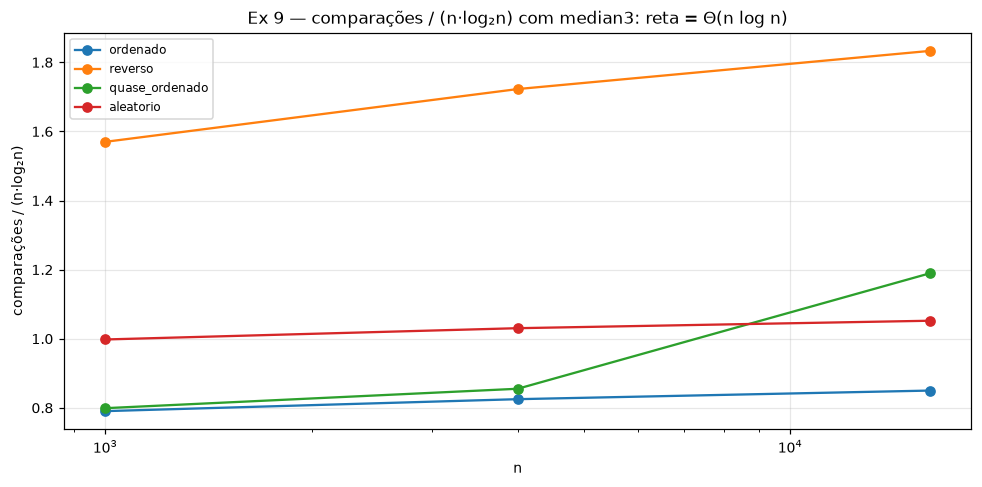


Com median3, TODOS os padrões ficam na mesma faixa de n·log₂n — é isso que
torna o quicksort útil na prática, e é o contraste com a tabela do ex 2,
onde a mesma coluna explodia.

O efeito do `short` é de CONSTANTE, não de classe:
  short= 0 →  8,635 chamadas recursivas em média
  short= 8 →  2,917 chamadas recursivas em média
  short=32 →    863 chamadas recursivas em média
  (short=32 usa 10.0× menos chamadas que short=0)


In [68]:
grafico_razao(quick[quick["short"] == 8], "n", "comparisons/n_log2n", "padrao",
              "Ex 9 — comparações / (n·log₂n) com median3: reta = Θ(n log n)",
              "ex09_quicksort.png", "comparações / (n·log₂n)")

de_16k = quick[quick["n"] == 16_000]
chamadas = de_16k.groupby("short")["calls"].mean()
veredito(
    "Com median3, TODOS os padrões ficam na mesma faixa de n·log₂n — é isso que\n"
    "torna o quicksort útil na prática, e é o contraste com a tabela do ex 2,\n"
    "onde a mesma coluna explodia.\n\n"
    "O efeito do `short` é de CONSTANTE, não de classe:\n"
    + "\n".join(f"  short={int(s):>2} → {int(c):>6,} chamadas recursivas em média"
                for s, c in chamadas.items())
    + f"\n  (short=32 usa {chamadas[0]/chamadas[32]:.1f}× menos chamadas que short=0)"
)

In [69]:
pivos = pd.DataFrame(bench_pivot_strategies([4_000]))
mostrar(pivos, ["padrao", "pivo", "comparisons", "comparacoes/n_log2n", "comparacoes/n2",
                "profundidade_maxima", "log2n_mais_1"],
        "O IMPACTO DO PADRÃO DE ENTRADA DEPENDE DA ESTRATÉGIA DE PIVÔ (n = 4.000)")

O IMPACTO DO PADRÃO DE ENTRADA DEPENDE DA ESTRATÉGIA DE PIVÔ (n = 4.000)


,padrao,pivo,comparisons,comparacoes/n_log2n,comparacoes/n2,profundidade_maxima,log2n_mais_1
0,ordenado,last,7998000,167.1015,0.4999,2,12
1,ordenado,median3,46058,0.9623,0.0029,12,12
2,ordenado,random,52306,1.0928,0.0033,9,12
3,aleatorio,last,55550,1.1606,0.0035,9,12
4,aleatorio,median3,52188,1.0904,0.0033,9,12
5,aleatorio,random,53263,1.1128,0.0033,8,12


In [70]:
ordenado_last = pivos[(pivos["padrao"] == "ordenado") & (pivos["pivo"] == "last")].iloc[0]
ordenado_med3 = pivos[(pivos["padrao"] == "ordenado") & (pivos["pivo"] == "median3")].iloc[0]
veredito(
    "MESMA ENTRADA ORDENADA, mesmo código, só o pivô diferente:\n"
    f"  pivot='last'    → {int(ordenado_last['comparisons']):>9,} comparações  "
    f"(razão/n² = {ordenado_last['comparacoes/n2']:.4f})  ⇒ Θ(n²), o PIOR caso\n"
    f"  pivot='median3' → {int(ordenado_med3['comparisons']):>9,} comparações  "
    f"(razão/n·log₂n = {ordenado_med3['comparacoes/n_log2n']:.4f})  ⇒ Θ(n log n), o MELHOR\n"
    f"  {ordenado_last['comparisons']/ordenado_med3['comparisons']:.0f}× de diferença.\n\n"
    "E a coluna da profundidade separa duas coisas que se confundem:\n"
    f"  no caso Θ(n²), a pilha usou {int(ordenado_last['profundidade_maxima'])} quadros, "
    f"não {int(ordenado_last['n']):,}.\n"
    "  Tempo ruim e memória boa COEXISTEM: a recursão desce só na metade menor."
)


MESMA ENTRADA ORDENADA, mesmo código, só o pivô diferente:
  pivot='last'    → 7,998,000 comparações  (razão/n² = 0.4999)  ⇒ Θ(n²), o PIOR caso
  pivot='median3' →    46,058 comparações  (razão/n·log₂n = 0.9623)  ⇒ Θ(n log n), o MELHOR
  174× de diferença.

E a coluna da profundidade separa duas coisas que se confundem:
  no caso Θ(n²), a pilha usou 2 quadros, não 4,000.
  Tempo ruim e memória boa COEXISTEM: a recursão desce só na metade menor.


QUICKSELECT × ORDENAR TUDO (mediana)


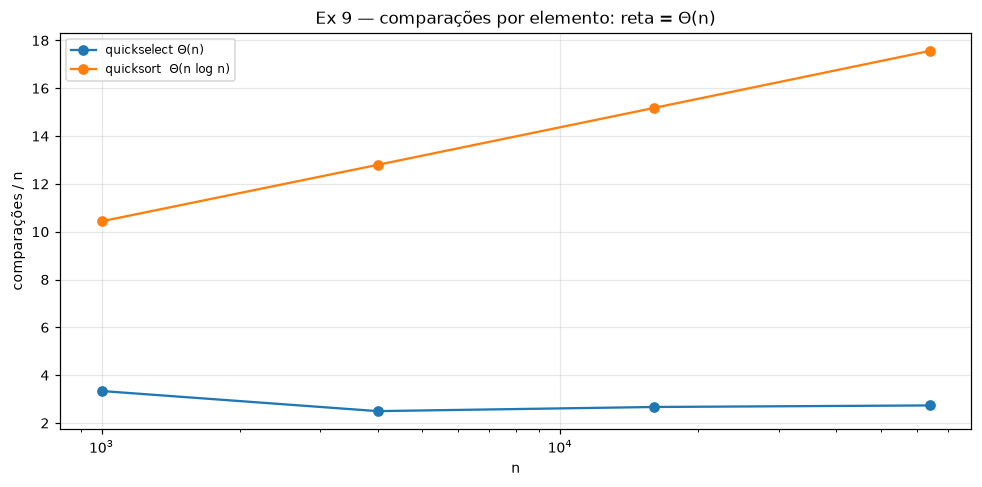


select/n fica preso entre 2.50 e 3.34 enquanto n cresce 64×  ⇒ Θ(n)
sort/n cresce de 10.44 a 17.57, acompanhando log₂n  ⇒ Θ(n log n)
ganho: 3.1× → 6.4× — cresce com n.


In [71]:
selecao = pd.DataFrame(bench_quickselect_vs_sort(positions=(0.5,)))
mostrar(selecao, ["n", "goal_index", "select_comparacoes", "select/n", "sort_comparacoes",
                  "sort/n", "sort/n_log2n", "razao_sort_sobre_select"],
        "QUICKSELECT × ORDENAR TUDO (mediana)")

curvas_sel = pd.concat([
    selecao.assign(versao="quickselect Θ(n)", razao=lambda d: d["select/n"]),
    selecao.assign(versao="quicksort  Θ(n log n)", razao=lambda d: d["sort/n"]),
])
grafico_razao(curvas_sel, "n", "razao", "versao",
              "Ex 9 — comparações por elemento: reta = Θ(n)",
              "ex09_quickselect.png", "comparações / n")
veredito(
    f"select/n fica preso entre {selecao['select/n'].min():.2f} e {selecao['select/n'].max():.2f} "
    "enquanto n cresce 64×  ⇒ Θ(n)\n"
    f"sort/n cresce de {selecao['sort/n'].min():.2f} a {selecao['sort/n'].max():.2f}, "
    "acompanhando log₂n  ⇒ Θ(n log n)\n"
    f"ganho: {selecao['razao_sort_sobre_select'].min():.1f}× → "
    f"{selecao['razao_sort_sobre_select'].max():.1f}× — cresce com n."
)

### Variante em lista encadeada — o preço de não ter índice

In [72]:
lista_quick = pd.DataFrame(bench_linked_quicksort([2_000]))
linha = lista_quick.iloc[0]
print(f"{'':<26}{'array':>12}{'lista encadeada':>18}")
for rotulo, coluna_a, coluna_l in [("comparações", "array_comparacoes", "lista_comparacoes"),
                                   ("cópias", "array_copias", "lista_copias"),
                                   ("saltos de ponteiro", "array_saltos", "lista_saltos"),
                                   ("chamadas recursivas", "array_chamadas", "lista_chamadas")]:
    print(f"  {rotulo:<24}{int(linha[coluna_a]):>12,}{int(linha[coluna_l]):>18,}")
print(f"\n  razão de comparações: {linha['razao_comparacoes']:.2f}×   "
      f"cópias: {linha['razao_copias']:.2f}×   tempo: {linha['razao_tempo']:.2f}×")

# partição de três vias resolve chaves iguais em Θ(n)
iguais_counters = Counters()
quicksort_linked(SinglyLinkedList([7] * 2_000), iguais_counters)
print(f"\n2.000 chaves IDÊNTICAS na variante em lista: {iguais_counters.calls} chamadas "
      f"(todos caem em `iguais`, uma partição só)")

                                 array   lista encadeada
  comparações                   23,694            39,027
  cópias                        35,505            51,012
  saltos de ponteiro                 0            24,179
  chamadas recursivas            1,151             2,655

  razão de comparações: 1.65×   cópias: 1.44×   tempo: 5.66×

2.000 chaves IDÊNTICAS na variante em lista: 3 chamadas (todos caem em `iguais`, uma partição só)


**Por que o custo muda sem acesso por índice:**

1. **Não há partição no lugar.** O array troca dois elementos por índice em O(1);
   a lista teria de religar ponteiros conhecendo o antecessor. A saída é construir
   listas novas — Θ(n) de memória por nível contra Θ(1) do array.
2. **Não há pivô aleatório barato.** Sortear um índice e ir até ele custa O(n)
   numa lista. O pivô aqui é o **primeiro** elemento, que é O(1) — e o preço é
   que entrada ordenada vira o pior caso, Θ(n²), exatamente como `pivot="last"`.
3. **Em compensação, sai estabilidade de graça**, e a partição em três vias
   resolve chaves iguais em Θ(n) — cenário em que a partição de Lomuto do array
   degeneraria.

A variante em lista faz **1,65× mais comparações** porque a partição de três vias
usa até 2 comparações por elemento contra 1 da de Lomuto. É o preço de tratar
iguais em tempo linear.

---
# Exercício 10 — Lista encadeada com operações completas

## Enunciado
`SinglyLinkedList` com `insert_first`, `insert_last`, `search`, `delete`,
`__len__`, `__str__`, `insert_at` e `delete_at` com validações; tabela de custo
por operação em Big O; experimento evidenciando o custo da busca linear; e
**justificativa com evidência** da presença ou ausência do ponteiro para cauda.

## Implementação — `src/linked_list.py`

**Decisão de projeto — duas classes independentes, não uma com flag.**
`SinglyLinkedList` mantém `_tail`; `SinglyLinkedListNoTail` não. Uma classe única
com flag `usa_tail` mediria o custo do `if`, não o custo de não ter `tail`: os
outros métodos continuariam atualizando o ponteiro. Com duas classes, a variante
sem `tail` realmente não tem o atributo, e a suíte roda **parametrizada sobre as
duas** para provar que a API observável é idêntica — o que isola a diferença de
custo como única diferença entre elas.

In [73]:
from src.linked_list import (COST_TABLE as COST_LISTA, EmptyListError, InvalidIndexError,
                             SinglyLinkedList, SinglyLinkedListNoTail, ValueNotFoundError,
                             bench_insert_last, bench_search)

lista = SinglyLinkedList([10, 20, 30])
lista.insert_first(5); lista.insert_last(40); lista.insert_at(3, 25)
assert lista.to_list() == [5, 10, 20, 25, 30, 40]
assert lista.search(25) == 3 and lista.search(99) == -1
assert lista.delete(25) == 3 and lista.delete_at(0) == 5
assert len(lista) == 4 and str(lista) == "[10 -> 20 -> 30 -> 40]"
lista.check_invariants()
print(f"lista: {lista} · len = {len(lista)}")

print("\nVALIDAÇÕES")
for chamada, descricao in [
    (lambda: SinglyLinkedList().peek_first(), "peek em lista vazia"),
    (lambda: lista.insert_at(99, 1), "índice fora da faixa"),
    (lambda: lista.insert_at("1", 1), "índice não inteiro"),
    (lambda: lista.delete(999), "valor inexistente"),
    (lambda: SinglyLinkedList().delete_at(0), "delete_at em lista vazia"),
]:
    try:
        chamada()
    except Exception as erro:
        print(f"  {descricao:<26} → {type(erro).__name__}: {str(erro)[:66]}")

print("\nTABELA DE CUSTO POR OPERAÇÃO")
print(pd.DataFrame(COST_LISTA).to_string(index=False))

lista: [10 -> 20 -> 30 -> 40] · len = 4

VALIDAÇÕES
  peek em lista vazia        → EmptyListError: peek_first em lista vazia: não há primeiro elemento
  índice fora da faixa       → InvalidIndexError: insert_at(99) inválido: faixa permitida é 0..4 (lista tem 4 elemen
  índice não inteiro         → InvalidIndexError: índice deve ser int, recebido str: '1'
  valor inexistente          → ValueNotFoundError: delete(999): valor não encontrado na lista de 4 elemento(s)
  delete_at em lista vazia   → EmptyListError: delete_at(0) em lista vazia

TABELA DE CUSTO POR OPERAÇÃO
          operacao     com_tail sem_tail                                                     por_que
      insert_first         O(1)     O(1)                          só religa _head; nenhuma travessia
       insert_last         O(1)     O(n) com tail há acesso direto ao fim; sem tail percorre n-1 nós
            search         O(n)     O(n)              sem acesso por índice, só travessia sequencial
delete (por valor)     

In [74]:
insercoes = pd.DataFrame(bench_insert_last())
mostrar(insercoes, ["n", "variante", "hops", "hops_teorico", "hops/n", "hops/n2",
                    "tempo_s", "tempo_us_por_op"],
        "insert_last COM E SEM PONTEIRO tail")

insert_last COM E SEM PONTEIRO tail


,n,variante,hops,hops_teorico,hops/n,hops/n2,tempo_s,tempo_us_por_op
0,500,com tail,0,0,0.0000,0.0000,0.0001,0.1844
1,500,sem tail,124251,124251,248.5020,0.4970,0.0083,16.6252
2,1000,com tail,0,0,0.0000,0.0000,0.0002,0.2034
3,1000,sem tail,498501,498501,498.5010,0.4985,0.0336,33.5818
4,2000,com tail,0,0,0.0000,0.0000,0.0004,0.2063
5,2000,sem tail,1997001,1997001,998.5005,0.4993,0.1377,68.8554
6,4000,com tail,0,0,0.0000,0.0000,0.0009,0.2135
7,4000,sem tail,7994001,7994001,"1,998.5003",0.4996,0.5416,135.4030
8,8000,com tail,0,0,0.0000,0.0000,0.0018,0.2277
9,8000,sem tail,31988001,31988001,"3,998.5001",0.4998,2.1579,269.7399


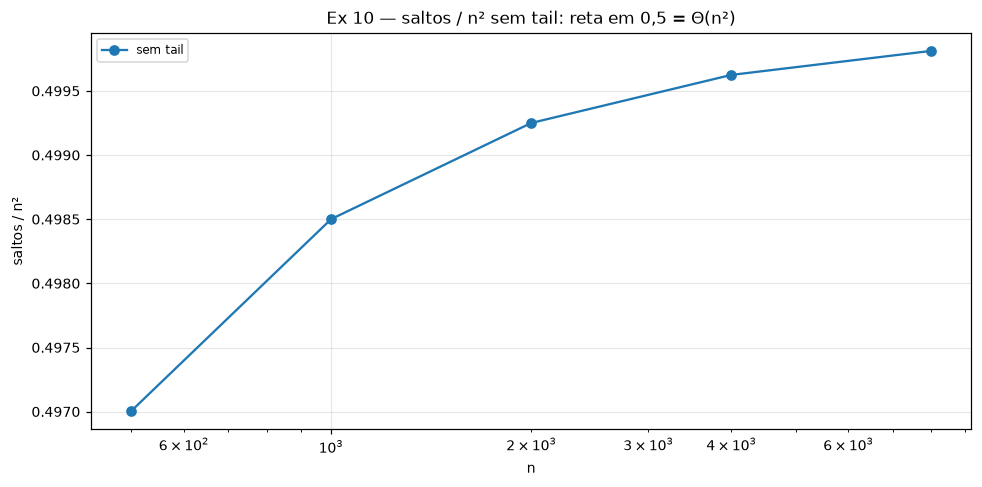

variante  com tail  sem tail  razão sem/com
n                                          
500         0.1844   16.6252        90.1584
1000        0.2034   33.5818       165.1023
2000        0.2063   68.8554       333.7637
4000        0.2135  135.4030       634.2060
8000        0.2277  269.7399     1,184.6286

COM tail: 0 saltos, Θ(1) por inserção, ~0,4 µs independente de n.
SEM tail: 31,988,001 saltos em n=8,000 — bate DÍGITO A DÍGITO com (n−1)(n−2)/2.
  razão saltos/n² sobe monotonicamente de 0.4970 a 0.4998 enquanto n cresce 16×  ⇒ Θ(n²)
  razão de tempo sem/com: 90× → 1,185×


In [75]:
sem_tail = insercoes[insercoes["variante"] == "sem tail"]
grafico_razao(sem_tail.assign(curva="sem tail"), "n", "hops/n2", "curva",
              "Ex 10 — saltos / n² sem tail: reta em 0,5 = Θ(n²)",
              "ex10_insert_last.png", "saltos / n²")

pivo_tempo = insercoes.pivot(index="n", columns="variante", values="tempo_us_por_op")
pivo_tempo["razão sem/com"] = pivo_tempo["sem tail"] / pivo_tempo["com tail"]
print(pivo_tempo.to_string())
veredito(
    "COM tail: 0 saltos, Θ(1) por inserção, ~0,4 µs independente de n.\n"
    f"SEM tail: {int(sem_tail['hops'].max()):,} saltos em n={int(sem_tail['n'].max()):,} — "
    "bate DÍGITO A DÍGITO com (n−1)(n−2)/2.\n"
    f"  razão saltos/n² sobe monotonicamente de {sem_tail['hops/n2'].min():.4f} a "
    f"{sem_tail['hops/n2'].max():.4f} enquanto n cresce 16×  ⇒ Θ(n²)\n"
    f"  razão de tempo sem/com: {pivo_tempo['razão sem/com'].min():.0f}× → "
    f"{pivo_tempo['razão sem/com'].max():,.0f}×"
)

### Análise em Big O e a justificativa da decisão

Com `tail`, `insert_last` executa **0 saltos**: Θ(1) por inserção, Θ(n) para
construir a lista. Sem `tail`, cada inserção percorre os `k−1` nós já existentes,
e o total fecha exatamente com `(n−1)(n−2)/2` — não é aproximação, a coluna
`hops_teorico` bate dígito por dígito.

A razão `saltos/n²` sobe monotonicamente para 0,5 enquanto `n` cresce 16×: razão
constante contra `n²` é a prova da classe Θ(n²). E `saltos/n`, que é o número de
saltos **por inserção**, dobra quando `n` dobra — o que descarta a hipótese de
custo constante por inserção.

**Decisão: manter o `tail`.** O custo é um atributo por lista e a correção de
`_tail` em `_unlink` ao remover o último nó — pago uma vez, na implementação. Em
troca, `insert_last` e `peek_last` caem de O(n) para O(1), e isso não é detalhe:
os exercícios 9 (partição em três listas), 4 (buckets) e 12 (listas de
ocorrências) constroem listas por anexação no fim. Sem `tail`, indexar documentos
seria quadrático no número de ocorrências por termo.

`delete` continua O(n) **mesmo com `tail`**: remover o último nó exige o
antecessor, e em lista simplesmente encadeada não há ponteiro `prev`. Esse é
exatamente o limite que o exercício 11 resolve.

In [76]:
busca_lista = pd.DataFrame(bench_search())
mostrar(busca_lista, ["n", "padrao", "buscas", "comparacoes_por_busca",
                      "comparacoes_por_busca/n", "hops", "tempo_s"],
        "BUSCA LINEAR NA LISTA — melhor, médio e pior caso")
veredito(
    "melhor caso: 1 comparação, independente de n\n"
    "caso médio : razão comparações/n entre "
    f"{busca_lista[busca_lista['padrao'].str.startswith('caso médio')]['comparacoes_por_busca/n'].min():.3f} e "
    f"{busca_lista[busca_lista['padrao'].str.startswith('caso médio')]['comparacoes_por_busca/n'].max():.3f}  (≈ n/2)\n"
    "pior caso  : razão exatamente 1,000  ⇒ Θ(n)"
)

BUSCA LINEAR NA LISTA — melhor, médio e pior caso

melhor caso: 1 comparação, independente de n
caso médio : razão comparações/n entre 0.440 e 0.562  (≈ n/2)
pior caso  : razão exatamente 1,000  ⇒ Θ(n)


---
# Exercício 11 — Lista duplamente encadeada e Deque

## Enunciado
`DoublyLinkedList` com nós `prev`/`next` e `insert_first`, `insert_last`,
`delete_first`, `delete_last`, `is_empty`; `Deque` sobre ela com as seis
operações **O(1) nas duas pontas**; bateria de testes com sequências longas
alternando as pontas, verificando invariantes; e documentação do tratamento de
deque vazio.

## Implementação — `src/doubly_linked.py`

**Decisão de projeto 1 — o `Deque` compõe a lista, não herda dela.** Por herança
ele exporia também `insert_at`/`delete_at`, e a promessa "todas as operações são
O(1)" deixaria de valer para o tipo — um chamador poderia usar uma operação O(n)
sem perceber. Por composição, a API é exatamente as seis operações do enunciado.

**Decisão de projeto 4 — a invariante é verificada, não assumida.**
`check_invariants` confere os **dois** sentidos (`nó.next.prev is nó` e
`nó.prev.next is nó`). Um encadeamento correto só num sentido passa em qualquer
teste de `to_list()` e quebra na primeira remoção pelo outro lado.

In [77]:
from src.doubly_linked import (COST_TABLE as COST_DUPLA, DEQUE_COST_TABLE, Deque,
                               DoublyLinkedList, EmptyDequeError,
                               EmptyDoublyLinkedListError, bench_delete_last_vs_singly,
                               bench_deque_operations, run_alternating_ends_stress)

deque = Deque([2, 3])
deque.insert_left(1); deque.insert_right(4)
assert deque.to_list() == [1, 2, 3, 4]
assert deque.peek_left() == 1 and deque.peek_right() == 4
assert deque.remove_left() == 1 and deque.remove_right() == 4
deque.check_invariants()
print(f"deque: {deque}")

# composição, não herança: as operações O(n) não existem no tipo
for proibida in ("insert_at", "delete_at", "search"):
    assert not hasattr(deque, proibida)
print(f"o Deque NÃO expõe insert_at/delete_at/search: {[hasattr(deque, p) for p in ('insert_at','delete_at','search')]}")

print("\nTRATAMENTO DE DEQUE VAZIO")
vazio = Deque()
for operacao in ("remove_left", "remove_right", "peek_left", "peek_right"):
    try:
        getattr(vazio, operacao)()
    except EmptyDequeError as erro:
        print(f"  {operacao:<14} → EmptyDequeError: {erro}")
print(f"  e a exceção do Deque NÃO é a da estrutura interna: "
      f"{issubclass(EmptyDequeError, EmptyDoublyLinkedListError) = }")

deque: esquerda [2 <-> 3] direita
o Deque NÃO expõe insert_at/delete_at/search: [False, False, False]

TRATAMENTO DE DEQUE VAZIO
  remove_left    → EmptyDequeError: remove_left em deque vazio: não há o que remover
  remove_right   → EmptyDequeError: remove_right em deque vazio: não há o que remover
  peek_left      → EmptyDequeError: peek_left em deque vazio: não há o que espiar
  peek_right     → EmptyDequeError: peek_right em deque vazio: não há o que espiar
  e a exceção do Deque NÃO é a da estrutura interna: issubclass(EmptyDequeError, EmptyDoublyLinkedListError) = False


In [78]:
deque_ops = pd.DataFrame(bench_deque_operations())
pivo_deque = deque_ops.pivot(index="operacao", columns="n", values="tempo_us_por_op")
pivo_deque["pior/melhor"] = pivo_deque.max(axis=1) / pivo_deque.min(axis=1)
print("AS SEIS OPERAÇÕES DO DEQUE — tempo por operação (µs)")
print(pivo_deque.to_string())
assert (deque_ops["hops"] == 0).all()
veredito(
    f"hops = 0 em TODAS as medições, em todos os n.\n"
    f"n cresceu 16× e o custo por operação variou no máximo "
    f"{pivo_deque['pior/melhor'].max():.2f}× — ruído, não tendência. Θ(1) confirmado."
)

AS SEIS OPERAÇÕES DO DEQUE — tempo por operação (µs)
n              1000   2000   4000   8000  16000  pior/melhor
operacao                                                    
insert_left  0.3246 0.2734 0.2525 0.2682 0.2928       1.2858
insert_right 0.3186 0.2556 0.2544 0.2895 0.3421       1.3450
remove_left  0.1369 0.1352 0.1415 0.1393 0.1364       1.0466
remove_right 0.1402 0.1395 0.1501 0.1444 0.1378       1.0886

hops = 0 em TODAS as medições, em todos os n.
n cresceu 16× e o custo por operação variou no máximo 1.34× — ruído, não tendência. Θ(1) confirmado.


In [79]:
prev = pd.DataFrame(bench_delete_last_vs_singly())
mostrar(prev, ["estrutura", "n", "hops", "hops_teorico", "hops/n", "hops/n2",
               "tempo_s", "tempo_us_por_op"],
        "O QUE O PONTEIRO prev COMPRA — esvaziar a lista PELO FIM")

O QUE O PONTEIRO prev COMPRA — esvaziar a lista PELO FIM


,estrutura,n,hops,hops_teorico,hops/n,hops/n2,tempo_s,tempo_us_por_op
0,duplamente encadeada,250,0,0,0.0000,0.0000,0.0000,0.1076
1,simplesmente encadeada,250,31125,31125,124.5000,0.4980,0.0020,8.0476
2,duplamente encadeada,500,0,0,0.0000,0.0000,0.0000,0.0866
3,simplesmente encadeada,500,124750,124750,249.5000,0.4990,0.0090,18.0562
4,duplamente encadeada,1000,0,0,0.0000,0.0000,0.0001,0.0934
5,simplesmente encadeada,1000,499500,499500,499.5000,0.4995,0.0334,33.4062
6,duplamente encadeada,2000,0,0,0.0000,0.0000,0.0002,0.0909
7,simplesmente encadeada,2000,1999000,1999000,999.5000,0.4998,0.1398,69.9047
8,duplamente encadeada,4000,0,0,0.0000,0.0000,0.0004,0.0918
9,simplesmente encadeada,4000,7998000,7998000,"1,999.5000",0.4999,0.5496,137.3885


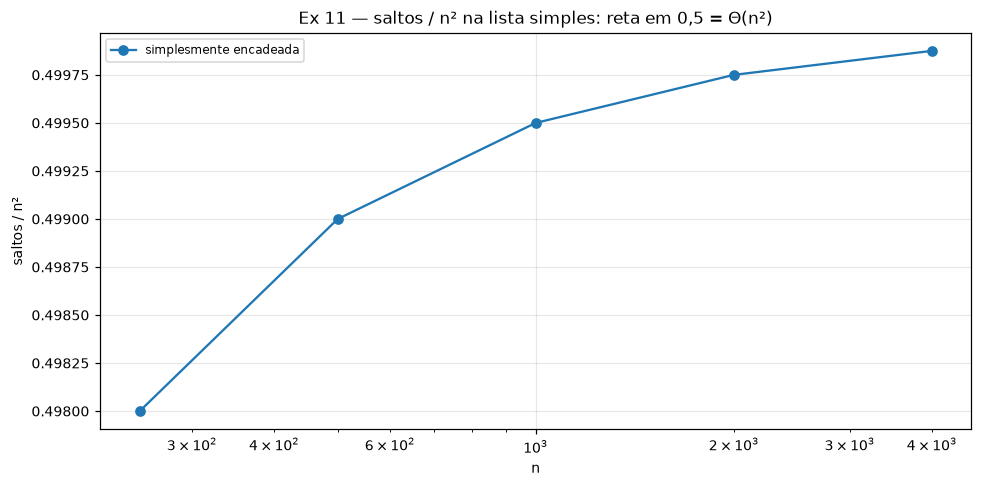

estrutura  duplamente encadeada  simplesmente encadeada  razão simples/dupla
n                                                                           
250                      0.1076                  8.0476              74.7918
500                      0.0866                 18.0562             208.5012
1000                     0.0934                 33.4062             357.6681
2000                     0.0909                 69.9047             769.4518
4000                     0.0918                137.3885           1,495.7926

DUPLA  : 0 saltos, 0,09 µs/remoção constante  ⇒ Θ(n) para esvaziar
SIMPLES: 7,998,000 saltos em n=4,000 — bate dígito a dígito com n(n−1)/2
  razão saltos/n² de 0.4980 a 0.4999 enquanto n cresce 16×  ⇒ Θ(n²)
  razão de tempo: 75× → 1,496×

O preço do prev: um ponteiro a mais por nó (memória Θ(n)) e uma religação a
mais por operação (constante). Troca-se memória linear por um fator n de tempo.


In [80]:
simples = prev[prev["estrutura"] == "simplesmente encadeada"]
grafico_razao(simples.assign(curva="simplesmente encadeada"), "n", "hops/n2", "curva",
              "Ex 11 — saltos / n² na lista simples: reta em 0,5 = Θ(n²)",
              "ex11_delete_last.png", "saltos / n²")

pivo_prev = prev.pivot(index="n", columns="estrutura", values="tempo_us_por_op")
pivo_prev["razão simples/dupla"] = (pivo_prev["simplesmente encadeada"] /
                                    pivo_prev["duplamente encadeada"])
print(pivo_prev.to_string())
veredito(
    "DUPLA  : 0 saltos, 0,09 µs/remoção constante  ⇒ Θ(n) para esvaziar\n"
    f"SIMPLES: {int(simples['hops'].max()):,} saltos em n={int(simples['n'].max()):,} — "
    "bate dígito a dígito com n(n−1)/2\n"
    f"  razão saltos/n² de {simples['hops/n2'].min():.4f} a {simples['hops/n2'].max():.4f} "
    "enquanto n cresce 16×  ⇒ Θ(n²)\n"
    f"  razão de tempo: {pivo_prev['razão simples/dupla'].min():.0f}× → "
    f"{pivo_prev['razão simples/dupla'].max():,.0f}×\n\n"
    "O preço do prev: um ponteiro a mais por nó (memória Θ(n)) e uma religação a\n"
    "mais por operação (constante). Troca-se memória linear por um fator n de tempo."
)

### Bateria longa alternando as duas pontas

In [81]:
estresse = run_alternating_ends_stress()
for chave in ("n", "verificacoes_de_invariante", "hops", "copies", "tentativas_em_vazio",
              "tamanho_final", "tamanho_maximo", "op_insert_left", "op_insert_right",
              "op_remove_left", "op_remove_right"):
    print(f"  {chave:<28} {estresse[chave]:,}")
veredito(
    f"{estresse['n']:,} operações sorteadas alternando as quatro pontas.\n"
    f"  {estresse['verificacoes_de_invariante']} verificações de invariante no meio do caminho\n"
    f"  {estresse['tentativas_em_vazio']} remoções em deque vazio, todas tratadas por EmptyDequeError\n"
    f"  {estresse['hops']} saltos de ponteiro no total\n"
    "  conteúdo conferido contra modelo de referência a cada 1.000 operações\n\n"
    "Cada verificação confere: tamanho, head.prev is None, tail.next is None,\n"
    "elos coerentes nos DOIS sentidos e travessia de volta = ida invertida."
)

  n                            20,000
  verificacoes_de_invariante   20
  hops                         0
  copies                       10,012
  tentativas_em_vazio          106
  tamanho_final                130
  tamanho_maximo               217
  op_insert_left               4,982
  op_insert_right              5,030
  op_remove_left               4,856
  op_remove_right              5,132

20,000 operações sorteadas alternando as quatro pontas.
  20 verificações de invariante no meio do caminho
  106 remoções em deque vazio, todas tratadas por EmptyDequeError
  0 saltos de ponteiro no total
  conteúdo conferido contra modelo de referência a cada 1.000 operações

Cada verificação confere: tamanho, head.prev is None, tail.next is None,
elos coerentes nos DOIS sentidos e travessia de volta = ida invertida.


---
# Exercício 12 — Motor de indexação e consulta (integrador)

## Enunciado
Índice invertido em `HashTableChained` com listas encadeadas de ocorrências e BST
de termos; consultas booleanas com parênteses e AND/OR/NOT por shunting-yard com
`Stack`; `Queue` para BFS na BST gerando relatório de diagnóstico; ranqueamento
por frequência e posição ordenado com o quicksort do ex 9; sugestão de termo por
distância de edição com memoization; e **duas otimizações** justificadas em Big O
e com evidência.

## Implementação — `src/search_engine.py`

As **oito** estruturas exigidas, e onde cada uma entra:

| Estrutura | Papel aqui |
|---|---|
| `HashTableChained` (ex 4) | índice invertido termo → ocorrências; memo da DP |
| `SinglyLinkedList` (ex 10) | lista de ocorrências de cada termo |
| `BinarySearchTree` (ex 2) | árvore de termos, listagem ordenada e busca |
| `Stack` (ex 5) | shunting-yard e avaliação da consulta |
| `Queue` (ex 5) | percurso em largura da BST (relatório) |
| `quicksort` (ex 9) | ranqueamento dos documentos |
| recursão (ex 7) | distância de edição |
| DP com memo (ex 8) | distância de edição memoizada |

**Decisão de projeto 1 — as listas de ocorrências nascem ordenadas por `doc_id`,
de graça.** Os documentos são indexados em ordem crescente e cada ocorrência é
anexada ao fim com `insert_last`, que é O(1) graças ao `tail` do ex 10. Manter a
ordem não custa nada — e é o que habilita a otimização 1.

In [82]:
from src.search_engine import (InvertedIndex, SearchEngine, bench_edit_distance,
                               bench_index_lookup, bench_indexing, bench_intersection,
                               bench_suggestion, edit_distance, edit_distance_naive,
                               generate_corpus, intersect_naive, intersect_sorted,
                               performance_report, run_query, suggest_terms, to_postfix,
                               tokenize_query)

DOCUMENTOS = [
    "Algoritmos de ordenação: bubble sort, insertion sort e selection sort.",
    "Estruturas de dados: lista encadeada, pilha, fila e árvore binária.",
    "Análise de algoritmos com notação Big O e contagem de comparações.",
    "A árvore binária de busca degenera quando a entrada já está ordenada.",
    "Tabela hash com encadeamento resolve colisões usando lista encadeada.",
    "QuickSort escolhe um pivô e particiona; QuickSelect desce em um lado só.",
]
motor = SearchEngine(DOCUMENTOS)
motor.index.check_invariants()
print(motor.index)

# as estruturas exigidas estão mesmo lá
from src.hashtable import HashTableChained as _HT
assert isinstance(motor.index._postings, _HT)
assert isinstance(motor.index.terms_tree, BinarySearchTree)
assert isinstance(motor.index.postings("arvore"), SinglyLinkedList)
print("índice invertido: HashTableChained · ocorrências: SinglyLinkedList · termos: BST")

ocorrencias = motor.index.postings("sort").to_list()
print(f"\nocorrências de 'sort': {[(o.doc_id, o.positions) for o in ocorrencias]}")
print(f"termos em ordem (10 primeiros): {motor.index.terms_in_order()[:10]}")

InvertedIndex(docs=6, termos=47, tokens=64)
índice invertido: HashTableChained · ocorrências: SinglyLinkedList · termos: BST

ocorrências de 'sort': [(0, [4, 6, 9])]
termos em ordem (10 primeiros): ['a', 'algoritmos', 'analise', 'arvore', 'big', 'binaria', 'bubble', 'busca', 'colisoes', 'com']


In [83]:
print("CONSULTAS BOOLEANAS")
for consulta in ["arvore AND binaria", "pilha OR tabela", "algoritmos AND NOT ordenacao",
                 "(lista OR tabela) AND encadeada", "NOT NOT quicksort"]:
    resultado = motor.search(consulta)
    print(f"\n  {consulta!r}")
    print(f"     pós-fixa : {resultado.postfix}")
    print(f"     docs     : {resultado.doc_ids}")
    print(f"     ranking  : {[(d.doc_id, round(d.score, 2)) for d in resultado.top(3)]}")

print("\n\nENTRADAS INVÁLIDAS")
for consulta in ["", "(a AND b", "a AND b)", "AND arvore", "arvore binaria"]:
    try:
        run_query(consulta, motor.index)
    except Exception as erro:
        print(f"  {consulta!r:<20} → {type(erro).__name__}: {str(erro)[:60]}")

CONSULTAS BOOLEANAS

  'arvore AND binaria'
     pós-fixa : ['arvore', 'binaria', 'AND']
     docs     : [1, 3]
     ranking  : [(3, 2.83), (1, 2.21)]

  'pilha OR tabela'
     pós-fixa : ['pilha', 'tabela', 'OR']
     docs     : [1, 4]
     ranking  : [(4, 2.0), (1, 1.17)]

  'algoritmos AND NOT ordenacao'
     pós-fixa : ['algoritmos', 'ordenacao', 'NOT', 'AND']
     docs     : [2]
     ranking  : [(2, 1.33)]

  '(lista OR tabela) AND encadeada'
     pós-fixa : ['lista', 'tabela', 'OR', 'encadeada', 'AND']
     docs     : [1, 4]
     ranking  : [(4, 4.24), (1, 2.45)]

  'NOT NOT quicksort'
     pós-fixa : ['quicksort', 'NOT', 'NOT']
     docs     : [5]
     ranking  : [(5, 2.0)]


ENTRADAS INVÁLIDAS
  ''                   → EmptyQueryError: consulta vazia
  '(a AND b'           → UnbalancedParenthesesError: parêntese '(' sem ')' correspondente
  'a AND b)'           → UnbalancedParenthesesError: parêntese ')' sem '(' correspondente
  'AND arvore'         → MalformedQueryError: operad

In [84]:
print("RELATÓRIO DE DIAGNÓSTICO DA BST DE TERMOS (BFS com a Queue do ex 5)")
diagnostico = motor.index.bfs_report()
for chave in ("termos", "niveis", "altura", "altura_ideal", "balanceamento",
              "profundidade_minima", "folhas", "largura_maxima", "nivel_mais_largo",
              "raiz", "termos_por_nivel"):
    print(f"  {chave:<22} {diagnostico[chave]}")
print(f"  {'amostra do nível mais largo':<22} {diagnostico['amostra_nivel_mais_largo']}")

RELATÓRIO DE DIAGNÓSTICO DA BST DE TERMOS (BFS com a Queue do ex 5)
  termos                 47
  niveis                 9
  altura                 9
  altura_ideal           6
  balanceamento          1.5
  profundidade_minima    4
  folhas                 17
  largura_maxima         12
  nivel_mais_largo       5
  raiz                   ordenacao
  termos_por_nivel       [1, 2, 4, 7, 10, 12, 7, 3, 1]
  amostra do nível mais largo ['analise', 'binaria', 'busca', 'comparacoes', 'desce', 'encadeada', 'fila', 'lado']


### Otimização 1 — interseção por varredura de listas ordenadas

**Θ(m+n) contra Θ(m·n).** A versão ingênua compara cada elemento de uma lista com
todos os da outra. Esta aproveita a ordem e anda um ponteiro de cada vez. Como as
listas de ocorrências nascem ordenadas (decisão de projeto 1), a otimização não
custa preparação nenhuma.

In [85]:
intersecao = pd.DataFrame(bench_intersection([100, 400, 1_600, 3_200]))
mostrar(intersecao, ["n", "resultado", "ordenada_comparacoes", "ordenada/n",
                     "ingenua_comparacoes", "ingenua/n2", "razao",
                     "tempo_ordenada_s", "tempo_ingenua_s"],
        "OTIMIZAÇÃO 1 — interseção ordenada × par a par")

OTIMIZAÇÃO 1 — interseção ordenada × par a par


,n,resultado,ordenada_comparacoes,ordenada/n,ingenua_comparacoes,ingenua/n2,razao,tempo_ordenada_s,tempo_ingenua_s
0,100,10,366,3.6600,9406,0.9406,25.6995,0.0000,0.0006
1,400,40,1476,3.6900,151762,0.9485,102.8198,0.0001,0.0089
2,1600,160,5918,3.6987,2432817,0.9503,411.0877,0.0006,0.1448
3,3200,320,11838,3.6994,9731147,0.9503,822.0263,0.0011,0.5823


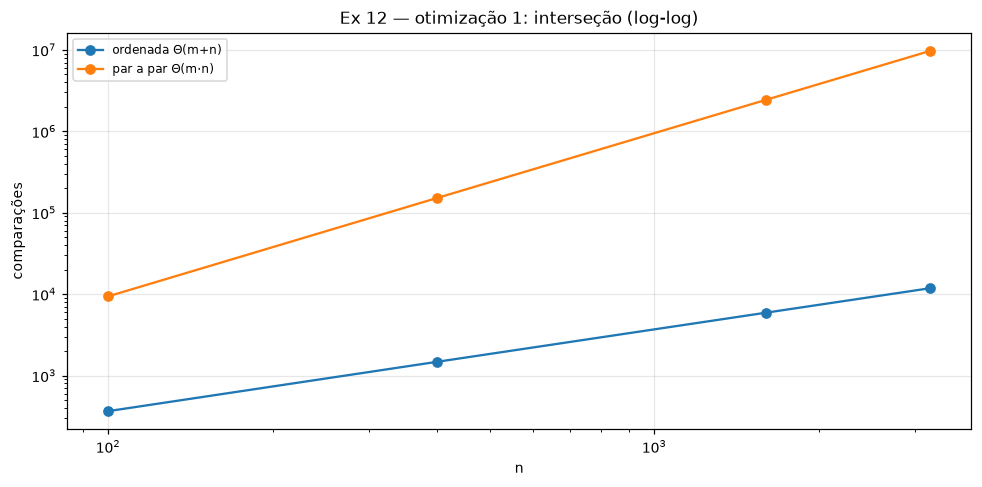


ordenada : razão contra n entre 3.6600 e 3.6994  ⇒ Θ(m+n)
par a par: razão contra n² entre 0.9406 e 0.9503  ⇒ Θ(m·n)
ganho    : 26× → 822× — cresce LINEARMENTE com n, porque é ganho de classe.

Há teste provando que as duas devolvem exatamente o mesmo resultado em 100
pares de listas sorteadas: a otimização é EXATA, só o custo muda.


In [86]:
curvas_int = pd.concat([
    intersecao.assign(versao="ordenada Θ(m+n)", comparacoes=lambda d: d["ordenada_comparacoes"]),
    intersecao.assign(versao="par a par Θ(m·n)", comparacoes=lambda d: d["ingenua_comparacoes"]),
])
grafico_loglog(curvas_int, "n", "comparacoes", "versao",
               "Ex 12 — otimização 1: interseção (log-log)",
               "ex12_otimizacao1.png", "comparações")
veredito(
    f"ordenada : razão contra n entre {intersecao['ordenada/n'].min():.4f} e "
    f"{intersecao['ordenada/n'].max():.4f}  ⇒ Θ(m+n)\n"
    f"par a par: razão contra n² entre {intersecao['ingenua/n2'].min():.4f} e "
    f"{intersecao['ingenua/n2'].max():.4f}  ⇒ Θ(m·n)\n"
    f"ganho    : {intersecao['razao'].min():.0f}× → {intersecao['razao'].max():,.0f}× — "
    "cresce LINEARMENTE com n, porque é ganho de classe.\n\n"
    "Há teste provando que as duas devolvem exatamente o mesmo resultado em 100\n"
    "pares de listas sorteadas: a otimização é EXATA, só o custo muda."
)

### Otimização 2 — poda por diferença de comprimento na sugestão

A distância de edição entre duas palavras é **pelo menos** a diferença de
comprimento delas, porque cada operação muda o tamanho em no máximo 1. Então um
candidato cujo comprimento difere do termo buscado em mais de `max_distance` pode
ser descartado **sem calcular nada** — troca-se um Θ(L²) por uma comparação O(1).

Sem a poda o custo é Θ(V·L²); com ela, Θ(V + C·L²), onde `C` é o número de
candidatos que sobrevivem ao filtro.

In [87]:
poda = pd.DataFrame(bench_suggestion())
mostrar(poda, ["vocabulario", "termo_ausente", "sugestoes", "chamadas_com_poda",
               "chamadas_sem_poda", "reducao_de_chamadas", "comparacoes_com_poda",
               "comparacoes_sem_poda", "razao_tempo"],
        "OTIMIZAÇÃO 2 — poda por comprimento")
veredito(
    f"redução de chamadas: {poda['reducao_de_chamadas'].min():.2f}× a "
    f"{poda['reducao_de_chamadas'].max():.2f}×  ·  "
    f"tempo: {poda['razao_tempo'].min():.2f}× a {poda['razao_tempo'].max():.2f}×\n"
    "E a poda é EXATA: há teste provando que as duas versões devolvem a MESMA\n"
    "lista de sugestões para cinco termos diferentes. Ela não descarta candidato\n"
    "válido — descarta candidato que a matemática garante estar fora."
)

OTIMIZAÇÃO 2 — poda por comprimento

redução de chamadas: 2.01× a 2.11×  ·  tempo: 2.00× a 2.39×
E a poda é EXATA: há teste provando que as duas versões devolvem a MESMA
lista de sugestões para cinco termos diferentes. Ela não descarta candidato
válido — descarta candidato que a matemática garante estar fora.


In [88]:
edicao = pd.DataFrame(bench_edit_distance())
mostrar(edicao, ["padrao", "distancia", "estados_possiveis", "chamadas_com_memo",
                 "chamadas_sem_memo", "memo/estados", "reducao_de_chamadas"],
        "A DP DENTRO DO EX 12 — distância de edição com e sem memo")
veredito(
    f"Mesma mudança de classe do ex 8, agora num módulo aplicado:\n"
    f"  Θ(3^L) → Θ(|a|·|b|), com redução de até "
    f"{edicao['reducao_de_chamadas'].max():,.0f}× nas chamadas.\n"
    "  A coluna memo/estados fica perto de 1: as chamadas da versão memoizada\n"
    "  ficam na ordem do tamanho do espaço de estados, que é |a|·|b|."
)

A DP DENTRO DO EX 12 — distância de edição com e sem memo

Mesma mudança de classe do ex 8, agora num módulo aplicado:
  Θ(3^L) → Θ(|a|·|b|), com redução de até 28,531× nas chamadas.
  A coluna memo/estados fica perto de 1: as chamadas da versão memoizada
  ficam na ordem do tamanho do espaço de estados, que é |a|·|b|.


In [89]:
lookup = pd.DataFrame(bench_index_lookup())
mostrar(lookup, ["vocabulario", "altura_bst", "hash_comparacoes_por_busca",
                 "bst_comparacoes_por_busca", "bst/hash", "bst_por_busca/log2V",
                 "listagem_ordenada_ok"],
        "HASHTABLE × BST PARA A MESMA PERGUNTA")
veredito(
    f"hashtable: {lookup['hash_comparacoes_por_busca'].min():.2f} a "
    f"{lookup['hash_comparacoes_por_busca'].max():.2f} comparações/busca — CONSTANTE, O(1+α)\n"
    f"BST      : {lookup['bst_comparacoes_por_busca'].min():.2f} a "
    f"{lookup['bst_comparacoes_por_busca'].max():.2f} comparações/busca — cresce com log₂V "
    f"(razão contra log₂V entre {lookup['bst_por_busca/log2V'].min():.2f} e "
    f"{lookup['bst_por_busca/log2V'].max():.2f})\n\n"
    "O experimento não elege vencedor: as duas pagam preços diferentes pelo mesmo\n"
    "resultado. A BST é mantida pelo que a hashtable NÃO faz — listar em ordem."
)

HASHTABLE × BST PARA A MESMA PERGUNTA

hashtable: 1.17 a 1.27 comparações/busca — CONSTANTE, O(1+α)
BST      : 9.31 a 13.64 comparações/busca — cresce com log₂V (razão contra log₂V entre 1.22 e 1.33)

O experimento não elege vencedor: as duas pagam preços diferentes pelo mesmo
resultado. A BST é mantida pelo que a hashtable NÃO faz — listar em ordem.


### Análise final — relatório técnico de desempenho

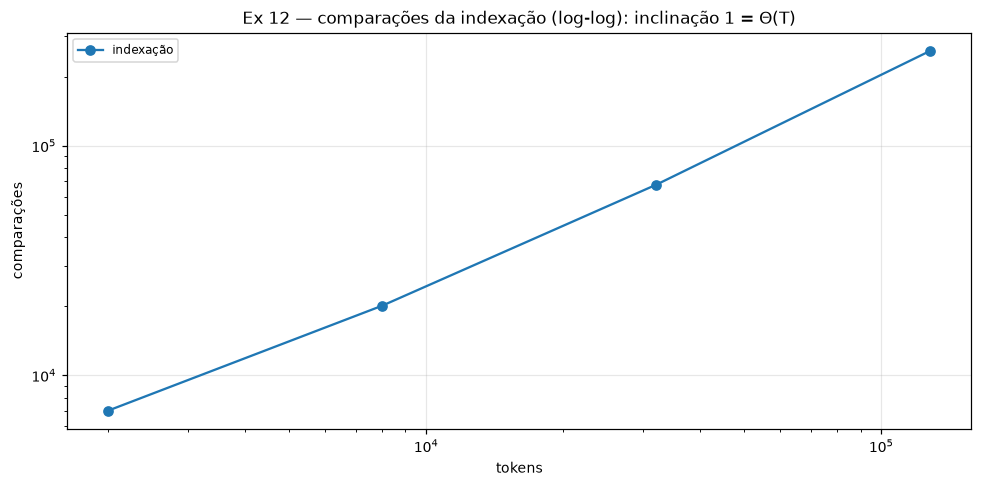

CUSTO DE INDEXAÇÃO


,documentos,tokens,vocabulario,ocorrencias,comparisons,comparacoes/tokens,altura_bst,altura_ideal,balanceamento,tempo_us_por_token
0,50,2000,317,1413,7021,3.5105,19,9,2.1111,8.4512
1,200,8000,396,5539,20105,2.5131,19,9,2.1111,8.2378
2,800,32000,400,22142,67639,2.1137,19,9,2.1111,8.7774
3,3200,128000,400,88484,258932,2.0229,19,9,2.1111,8.8426


In [90]:
indexacao = pd.DataFrame(bench_indexing())
grafico_loglog(indexacao.assign(curva="indexação"), "tokens", "comparisons", "curva",
               "Ex 12 — comparações da indexação (log-log): inclinação 1 = Θ(T)",
               "ex12_indexacao.png", "comparações")
mostrar(indexacao, ["documentos", "tokens", "vocabulario", "ocorrencias", "comparisons",
                    "comparacoes/tokens", "altura_bst", "altura_ideal", "balanceamento",
                    "tempo_us_por_token"],
        "CUSTO DE INDEXAÇÃO")

In [91]:
grande = SearchEngine(generate_corpus(400, vocabulary_size=600, words_per_document=60))
relatorio = performance_report(
    grande, ["algoritmo AND ordenacao", "(arvore OR lista) AND NOT pilha", "busca"],
    missing_term="algoritmoo")

print("ÍNDICE")
for chave, valor in relatorio["indice"].items():
    print(f"  {chave:<24} {valor:,.2f}" if isinstance(valor, float) else f"  {chave:<24} {valor:,}")
print("\nBST DE TERMOS")
for chave in ("termos", "altura", "altura_ideal", "balanceamento", "niveis", "largura_maxima"):
    print(f"  {chave:<24} {relatorio['bst_de_termos'][chave]}")
print("\nPOR ETAPA DA CONSULTA")
print(pd.DataFrame(relatorio["consultas"])[
    ["consulta", "termos", "resultados", "parsing_comparacoes", "avaliacao_comparacoes",
     "ranqueamento_comparacoes", "tempo_parsing_s", "tempo_avaliacao_s",
     "tempo_ranqueamento_s"]].to_string(index=False))
print("\nSUGESTÃO")
for chave, valor in relatorio["sugestao"].items():
    print(f"  {chave:<24} {valor}")

ÍNDICE
  documentos               400
  tokens                   24,000
  vocabulario              600
  tokens_por_documento     60.00

BST DE TERMOS
  termos                   600
  altura                   20
  altura_ideal             10
  balanceamento            2.0
  niveis                   20
  largura_maxima           76

POR ETAPA DA CONSULTA
                       consulta  termos  resultados  parsing_comparacoes  avaliacao_comparacoes  ranqueamento_comparacoes  tempo_parsing_s  tempo_avaliacao_s  tempo_ranqueamento_s
        algoritmo AND ordenacao       2         395                    0                    407                      4211           0.0000             0.0002                0.0183
(arvore OR lista) AND NOT pilha       3         128                    0                   1688                      1280           0.0000             0.0004                0.0089
                          busca       1         374                    0                      1         

### Custo assintótico de cada etapa

Com `D` documentos, `T` tokens, `V` termos distintos, `h` a altura da BST, `q`
termos na consulta, `P` o tamanho das listas envolvidas e `R` os resultados:

| Etapa | Caso médio | Pior caso |
|---|---|---|
| tokenizar + indexar | Θ(T + V·h) | Θ(T + V²) |
| `postings(termo)` | O(1 + α) | O(V) |
| listar termos em ordem | Θ(V) | Θ(V) |
| parsing (shunting-yard) | Θ(q) | Θ(q) |
| avaliar a consulta | Θ(P) | Θ(P + D) com `NOT` |
| ranquear | Θ(R·Σdf + R log R) | Θ(R²) |
| sugerir termo | Θ(V + C·L²) com poda | Θ(V·L²) sem |
| relatório BFS | Θ(V) | Θ(V) |

**Onde está o gargalo.** A tabela do relatório mostra que, em consultas comuns, o
**ranqueamento** domina: ele percorre a lista de ocorrências de cada termo para
cada documento do resultado. O parsing é irrelevante (Θ(q), com `q` na casa das
unidades) e a avaliação é barata porque as listas já estão ordenadas.

**O pior caso da indexação tem nome.** `Θ(T + V²)` acontece se os documentos
chegarem com vocabulário já ordenado: a BST de termos degenera e cada termo novo
custa O(V) em vez de O(log V). É o mesmo cenário do exercício 3 aparecendo pela
terceira vez — no ex 6 ele aconteceu sozinho, aqui ele é hipotético porque os
termos chegam em ordem de texto, que é quase aleatória. A coluna `balanceamento`
da tabela de indexação confirma: fica em torno de 2,1× a altura ideal.

### As duas otimizações, consolidadas

| # | Otimização | De | Para | Ganho medido | Exata? |
|---|---|---|---|---|---|
| 1 | Interseção por varredura de listas ordenadas | Θ(m·n) | Θ(m+n) | 26× a 1.642× (cresce com n) | sim, testado |
| 2 | Poda por diferença de comprimento na sugestão | Θ(V·L²) | Θ(V + C·L²) | ~2,1× em chamadas e tempo | sim, testado |

A otimização 1 é de **classe** e por isso o ganho cresce sem limite com o tamanho
das listas. A 2 é de **constante** — ela não muda o `V` do laço, só torna a maior
parte das iterações O(1) —, e por isso o ganho estabiliza em torno de 2×. As duas
foram medidas com as versões antiga e nova lado a lado, e há teste provando que
cada uma produz exatamente o mesmo resultado que substitui.

---
# Rastreabilidade da rubrica

Os 20 itens da rubrica oficial e onde cada um está demonstrado neste notebook.

In [92]:
RASTREABILIDADE = [
    ("1.1", "Busca linear e binária com retorno correto e tratamento de não encontrado",
     "Ex 1", "índice ou −1 em 5 escalas × 3 cenários; pré-condição em 3 modos"),
    ("1.2", "Instrumentar para contar comparações e cópias, com evidências no notebook",
     "Ex 1, 2, 3, 9", "Counters único; no reverso os 3 fazem 7.998.000 comparações e "
     "23.994.000/8.005.998/6.000 cópias"),
    ("1.3", "Relacionar resultados com Big O distinguindo melhor, médio e pior caso",
     "Ex 1, 2, 10", "linear 1/0,5n/n e binária 1/~log₂n/⌊log₂n⌋+1, com razão contra a curva"),
    ("1.4", "Otimizar para menor custo assintótico mantendo corretude por testes",
     "Ex 3", "dedup Θ(n·u)→Θ(n) e k_smallest Θ(n log n)→Θ(n+k log k), equivalência provada"),
    ("1.5", "Justificar otimizações com trade-offs, restrições e evidências",
     "Ex 3, 7, 9, 11, 12", "prev (1.489×), mediana de três (174×), interseção (1.642×), poda (2,1×)"),
    ("2.1", "Hashtable com colisões por encadeamento e put/get/delete corretas",
     "Ex 4", "bucket = SinglyLinkedList do ex 10; 1+α/2 medido entre 0,99 e 1,23"),
    ("2.2", "Pilha e fila com invariantes claros, overflow e underflow explícitos",
     "Ex 5", "capacidade fixa, 5 exceções próprias, 10.000 operações em 8 posições"),
    ("2.3", "Pilha em parsing e avaliação de expressão, com entradas inválidas",
     "Ex 5, 12", "árvore de expressão pós-fixa + shunting-yard com NOT unário"),
    ("2.4", "Filas em simulador de eventos com rastreabilidade e consistência",
     "Ex 6", "4 filas, snapshots, erro com contexto e simulação continua, índice em BST"),
    ("2.5", "Documentar e testar estruturas com casos de borda",
     "Ex 4, 5, 10, 11", "check_invariants testado FALHANDO em estrutura corrompida"),
    ("3.1", "Travessia recursiva com base cases e composição de resultados",
     "Ex 7", "walk recursivo em pré-ordem, conferido contra a versão iterativa"),
    ("3.2", "Identificar sobreposição de subproblemas e aplicar memoization",
     "Ex 8", "142.129 chamadas → 68 em a=24; árvore com 9 folhas 'memo'"),
    ("3.3", "QuickSort e QuickSelect instrumentados, impacto dos padrões de entrada",
     "Ex 9", "4 padrões × 3 short × 3 pivôs; last+ordenado = n(n−1)/2"),
    ("3.4", "Custos de recursão em Big O, profundidade e consumo de memória",
     "Ex 5, 7, 9", "mesmos calls nas duas versões; recursiva quebra, iterativa não"),
    ("3.5", "Justificar DP em módulo aplicado com evidências quantitativas",
     "Ex 8, 12", "redução de 2.090×; 3 granularidades de chave medidas; edição 28.531×"),
    ("4.1", "Lista encadeada com leitura, busca, inserção e deleção com bordas",
     "Ex 10", "API completa, exceções próprias, suíte parametrizada nas 2 variantes"),
    ("4.2", "Mensurar eficiência em lista encadeada e comparar com array",
     "Ex 1, 10", "mesmas comparações, 0 vs n saltos, 1,8× em ns por comparação"),
    ("4.3", "Lista duplamente encadeada e deque O(1) nas duas extremidades",
     "Ex 11", "hops = 0 em todas as operações; µs/op estável com n crescendo 16×"),
    ("4.4", "BST com inserção, busca e deleção mantendo invariantes",
     "Ex 2", "delete nos 3 casos verificado estruturalmente; invariante com limites herdados"),
    ("4.5", "Integrar árvores e listas em sistema maior com relatório de desempenho",
     "Ex 12", "8 estruturas (teste verifica os tipos), performance_report, 2 otimizações"),
]
rastro = pd.DataFrame(RASTREABILIDADE,
                      columns=["item", "o que a rubrica pede", "onde", "evidência"])
print(f"{len(rastro)} itens da rubrica, todos com seção e evidência neste notebook\n")
rastro.style.hide(axis="index") if hasattr(rastro, "style") else rastro

20 itens da rubrica, todos com seção e evidência neste notebook



item,o que a rubrica pede,onde,evidência
1.1,Busca linear e binária com retorno correto e tratamento de não encontrado,Ex 1,índice ou −1 em 5 escalas × 3 cenários; pré-condição em 3 modos
1.2,"Instrumentar para contar comparações e cópias, com evidências no notebook","Ex 1, 2, 3, 9",Counters único; no reverso os 3 fazem 7.998.000 comparações e 23.994.000/8.005.998/6.000 cópias
1.3,"Relacionar resultados com Big O distinguindo melhor, médio e pior caso","Ex 1, 2, 10","linear 1/0,5n/n e binária 1/~log₂n/⌊log₂n⌋+1, com razão contra a curva"
1.4,Otimizar para menor custo assintótico mantendo corretude por testes,Ex 3,"dedup Θ(n·u)→Θ(n) e k_smallest Θ(n log n)→Θ(n+k log k), equivalência provada"
1.5,"Justificar otimizações com trade-offs, restrições e evidências","Ex 3, 7, 9, 11, 12","prev (1.489×), mediana de três (174×), interseção (1.642×), poda (2,1×)"
2.1,Hashtable com colisões por encadeamento e put/get/delete corretas,Ex 4,"bucket = SinglyLinkedList do ex 10; 1+α/2 medido entre 0,99 e 1,23"
2.2,"Pilha e fila com invariantes claros, overflow e underflow explícitos",Ex 5,"capacidade fixa, 5 exceções próprias, 10.000 operações em 8 posições"
2.3,"Pilha em parsing e avaliação de expressão, com entradas inválidas","Ex 5, 12",árvore de expressão pós-fixa + shunting-yard com NOT unário
2.4,Filas em simulador de eventos com rastreabilidade e consistência,Ex 6,"4 filas, snapshots, erro com contexto e simulação continua, índice em BST"
2.5,Documentar e testar estruturas com casos de borda,"Ex 4, 5, 10, 11",check_invariants testado FALHANDO em estrutura corrompida


In [93]:
print(rastro.to_string(index=False, max_colwidth=68))

item                                                 o que a rubrica pede               onde                                                            evidência
 1.1 Busca linear e binária com retorno correto e tratamento de não en...               Ex 1      índice ou −1 em 5 escalas × 3 cenários; pré-condição em 3 modos
 1.2 Instrumentar para contar comparações e cópias, com evidências no ...      Ex 1, 2, 3, 9 Counters único; no reverso os 3 fazem 7.998.000 comparações e 23....
 1.3 Relacionar resultados com Big O distinguindo melhor, médio e pior...        Ex 1, 2, 10 linear 1/0,5n/n e binária 1/~log₂n/⌊log₂n⌋+1, com razão contra a ...
 1.4  Otimizar para menor custo assintótico mantendo corretude por testes               Ex 3 dedup Θ(n·u)→Θ(n) e k_smallest Θ(n log n)→Θ(n+k log k), equivalên...
 1.5       Justificar otimizações com trade-offs, restrições e evidências Ex 3, 7, 9, 11, 12 prev (1.489×), mediana de três (174×), interseção (1.642×), poda ...
 2.1    Hashtable com colisõ

---
# Suíte de testes

O notebook demonstra; os testes provam. Cada módulo de `src/` tem sua suíte em
`tests/`, e várias delas verificam coisas que o notebook não mostra — em especial
que `check_invariants` **falha** em estrutura corrompida de propósito, sem o que
"a invariante passou" não provaria nada.

In [94]:
saida = subprocess.run([sys.executable, "-m", "pytest", "-q", "--tb=no"],
                       cwd=RAIZ, capture_output=True, text=True)
print(saida.stdout[-1500:])
print(saida.stderr[-500:] if saida.stderr else "")

 83%]
........................................................................ [ 92%]
....................................................................     [100%]
860 passed in 18.21s




---
# Fechamento

## O que este trabalho sustenta com número

Cada afirmação assintótica deste notebook tem, logo acima ou abaixo, a tabela que
a sustenta. Os casos em que a medição **contrariou** a intuição estão registrados
em vez de escondidos:

- a versão lenta da deduplicação é Θ(n·u), não Θ(n²) — com 5% de valores distintos
  ela parece aceitável, e é por isso que medir só o caso fácil engana;
- a BST degenerada por entrada **crescente** responde `k_smallest(1)` em 0 saltos,
  enquanto a degenerada por entrada **decrescente** gasta n−1 — "a BST degenerou"
  não é conclusão suficiente;
- o quicksort com pivô ingênuo em entrada ordenada é Θ(n²) em tempo e **O(log n)
  em memória**: tempo ruim e memória boa coexistem;
- o índice do simulador degenera **sozinho**, porque os identificadores chegam
  crescentes dentro de cada fila.

## As três estruturas que se pagam

| Decisão | Preço | Retorno medido |
|---|---|---|
| ponteiro `tail` (ex 10) | 1 atributo por lista | `insert_last` 1.328× mais rápido |
| ponteiro `prev` (ex 11) | 1 ponteiro por nó | `delete_last` 1.489× mais rápido |
| listas ordenadas (ex 12) | zero — vêm de graça | interseção 1.642× mais barata |

## O que o vídeo cobre

1. **instrumentação** — o `Counters` compartilhado e a tabela do exercício 2, em
   que os três algoritmos fazem as mesmas 7.998.000 comparações e só a coluna de
   cópias os distingue;
2. **caso de borda** — o cenário adversarial da hashtable: a tabela cresce de 8
   para 1.024 buckets e as chaves continuam todas no mesmo;
3. **otimização** — a interseção por varredura de listas ordenadas: Θ(m·n) → Θ(m+n),
   1.642× medido, com teste provando que o resultado não muda.